Using a subsample of r in the model eleviated some problems, like initialization errors of the gp when using (0,0,0).
Also fixed the memory error during gp calculation.

How to sample the other parameters in the model?

Finding interpolation rutine implemented in jax.
Current one only supports linear interpolation, while cubic would be prefered.
Maybe use jax_cosmo.scipy.interpolate. Suggestions?

Memory problems when using a 200x200 image. 100x100 works for now.
Currently testing our older implementation on bigger grids, current maximum was 500x500 grid with a runtime of 12-20 minutes. testing of larger grids still in progress.
This was with only one free parameter.


    #sigma_p = numpyro.sample("sigma_p", dist.HalfNormal(1.))
    #length_scale_p = numpyro.sample("length_scale_p", dist.HalfNormal(0.1))

    #add log error in observed image do same in model log image sample log error obver gaussian distribution done
    # add plot loss over svi steps done
    # add predictive
    # add deterministic


    # do longer runs to see if std converges and larger noise try up to 50%
    # add deterministic to sb and calculate mean/std
    # try different inital p function
    # observe_image - mean predition / std_pred instead of residual

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import jax.numpy as jnp
from jax import grad, vmap
from matplotlib.colors import LogNorm
import jax
import random

from JAX_Deprojection import surface_brightness as sb
from JAX_Deprojection import density_distribution as den
import jax
import numpyro
import numpyro.distributions as dist
from tinygp import kernels, GaussianProcess
from numpyro.infer.autoguide import AutoNormal, AutoDelta
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.optim import Adam
from jax.scipy.interpolate import RegularGridInterpolator

In [2]:

'''
s_def = 1. 

e_k_def = 0.0 
e_d_def = 0.0

p_a_def = 0.00160907
p_b_def = -0.02122767
p_c_def = 0.07711992
p_d_def = 0.54249868

q_a_def = 0.0
q_b_def = 0.0
q_c_def = 0.0
q_d_def = 0.6

a_def = 2.
b_def = 4.
rho0_def = 0.001
i_def = 0.
phi_def = 0.
theta_def = 0.

size = 100
extent = 5
extents = [-extent, extent,-extent, extent]
'''

'\ns_def = 1. \n\ne_k_def = 0.0 \ne_d_def = 0.0\n\np_a_def = 0.00160907\np_b_def = -0.02122767\np_c_def = 0.07711992\np_d_def = 0.54249868\n\nq_a_def = 0.0\nq_b_def = 0.0\nq_c_def = 0.0\nq_d_def = 0.6\n\na_def = 2.\nb_def = 4.\nrho0_def = 0.001\ni_def = 0.\nphi_def = 0.\ntheta_def = 0.\n\nsize = 100\nextent = 5\nextents = [-extent, extent,-extent, extent]\n'

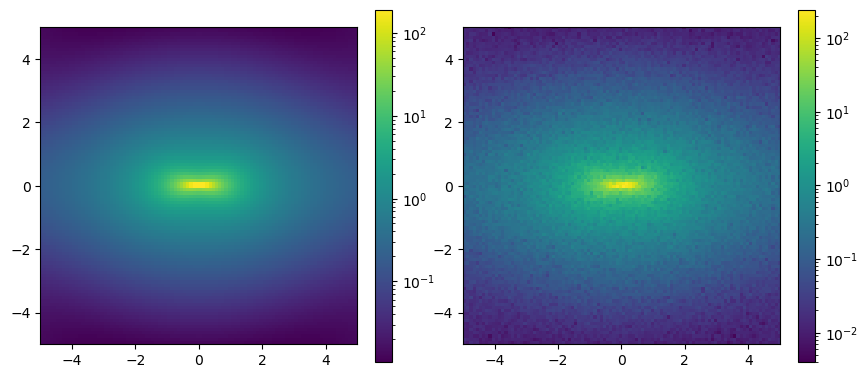

In [3]:
def create_dummy_image(e_k_def, e_d_def, p_a_def, p_b_def, p_c_def, p_d_def, q_a_def, q_b_def, q_c_def, q_d_def, rho0_def, s_def, a_def, b_def, i_def, phi_def, theta_def,error_fraction):

    size = 100
    extent = 5
    extents = [-extent, extent,-extent, extent]

    fig, (ax1,ax2) = plt.subplots(1, 2,figsize=(10, 10))

    sb_1= sb.Surface_brightness()
    sb_1.generate(size,extent, e_k_def, e_d_def, p_a_def, p_b_def, p_c_def, p_d_def, q_a_def, q_b_def, q_c_def, q_d_def, rho0_def, s_def, a_def, b_def, i_def, phi_def, theta_def)
    im1 = ax1.imshow(sb_1.data.T, norm=colors.LogNorm(), origin='lower',extent = extents)
    fig.colorbar(im1,ax=ax1,fraction = 0.05)

    key = jax.random.PRNGKey(42)
    noise = jax.random.normal(key, shape=sb_1.data.shape) * (error_fraction * sb_1.data)
    noisy_data = jnp.clip(sb_1.data + noise, 1e-6, None)

    im2 = ax2.imshow(noisy_data.T, norm=colors.LogNorm(), origin='lower',extent = extents)
    fig.colorbar(im2,ax=ax2,fraction = 0.05)


    return noisy_data, extents,size

s_def = 1. 

e_k_def = 0.0 
e_d_def = 0.0

q_a_def = 0.0
q_b_def = 0.0
q_c_def = 0.0
q_d_def = 0.6

a_def = 2.
b_def = 4.
rho0_def = 1.
i_def = 0.
phi_def = 0.
theta_def = 0.

p_input_params=[]
p_a_def = 0.00914918
p_b_def = -0.12086247
p_c_def = 0.44761072
p_d_def = 0.07762238
p1 = [p_a_def,p_b_def,p_c_def,p_d_def]
p_input_params.append(p1)

poly_extreme_data, extents, size = create_dummy_image(e_k_def,e_d_def,p_a_def,p_b_def,p_c_def,p_d_def,q_a_def,q_b_def,q_c_def,q_d_def,
                                                      rho0_def,s_def,a_def,b_def,i_def,phi_def,theta_def,0.2)


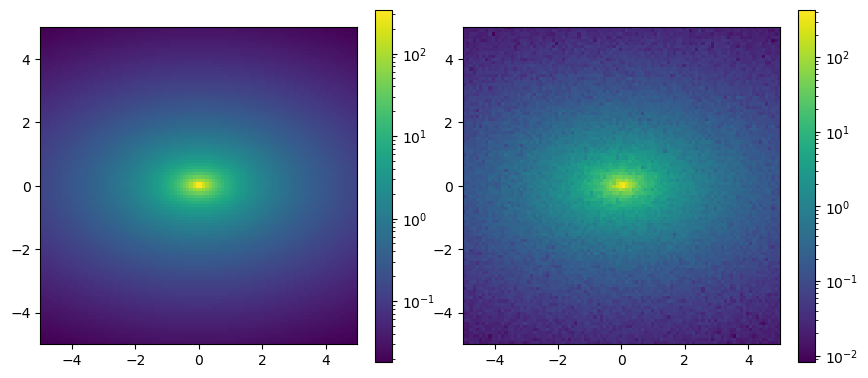

In [4]:
p_a_def = 0.00160907
p_b_def = -0.02122767
p_c_def = 0.07711992
p_d_def = 0.54249868
p2 = [p_a_def,p_b_def,p_c_def,p_d_def]
p_input_params.append(p2)

poly_flat_data, extents, size = create_dummy_image(e_k_def,e_d_def,p_a_def,p_b_def,p_c_def,p_d_def,q_a_def,q_b_def,q_c_def,q_d_def,
                                                   rho0_def,s_def,a_def,b_def,i_def,phi_def,theta_def,0.2)

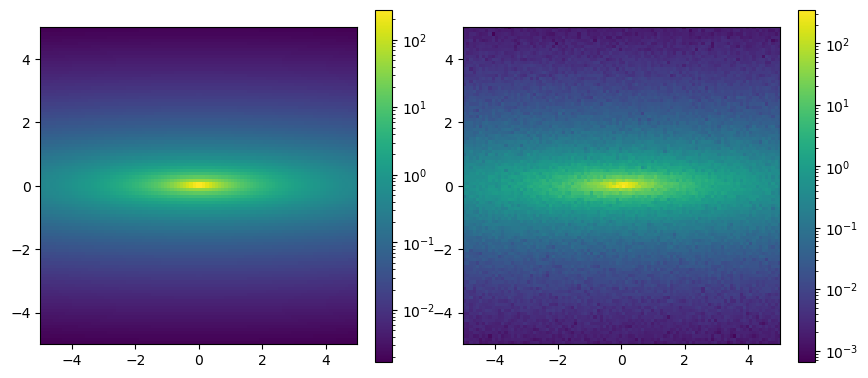

In [5]:
p_a_def = 0.0
p_b_def = 0.0
p_c_def = 0.0
p_d_def = 0.2
p3 = [p_a_def,p_b_def,p_c_def,p_d_def]
p_input_params.append(p3)

const_low_data, extents, size = create_dummy_image(e_k_def,e_d_def,p_a_def,p_b_def,p_c_def,p_d_def,q_a_def,q_b_def,q_c_def,q_d_def,
                                                   rho0_def,s_def,a_def,b_def,i_def,phi_def,theta_def,0.2)

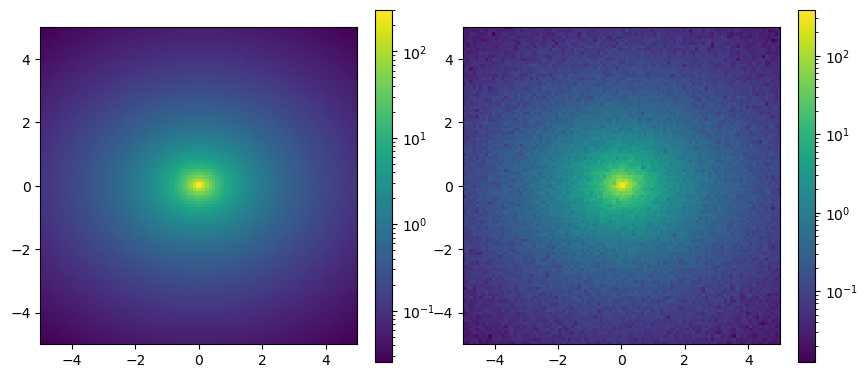

In [6]:
p_a_def = 0.0
p_b_def = 0.0
p_c_def = 0.0
p_d_def = 0.8
p4 = [p_a_def,p_b_def,p_c_def,p_d_def]
p_input_params.append(p4)

const_high_data, extents, size = create_dummy_image(e_k_def,e_d_def,p_a_def,p_b_def,p_c_def,p_d_def,q_a_def,q_b_def,q_c_def,q_d_def,
                                                    rho0_def,s_def,a_def,b_def,i_def,phi_def,theta_def,0.2)

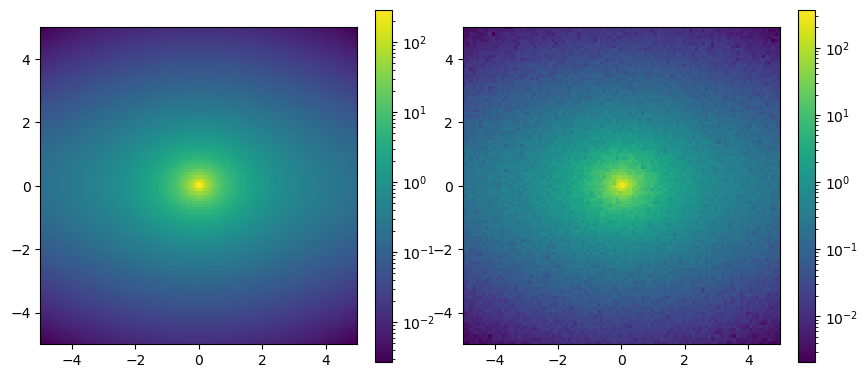

In [7]:
p_a_def = 0.
p_b_def = 0.
p_c_def = -0.088
p_d_def = 0.9
p5 = [p_a_def,p_b_def,p_c_def,p_d_def]
p_input_params.append(p5)
linear_decline_data, extents, size = create_dummy_image(e_k_def,e_d_def,p_a_def,p_b_def,p_c_def,p_d_def,q_a_def,q_b_def,q_c_def,q_d_def,
                                                        rho0_def,s_def,a_def,b_def,i_def,phi_def,theta_def,0.2)

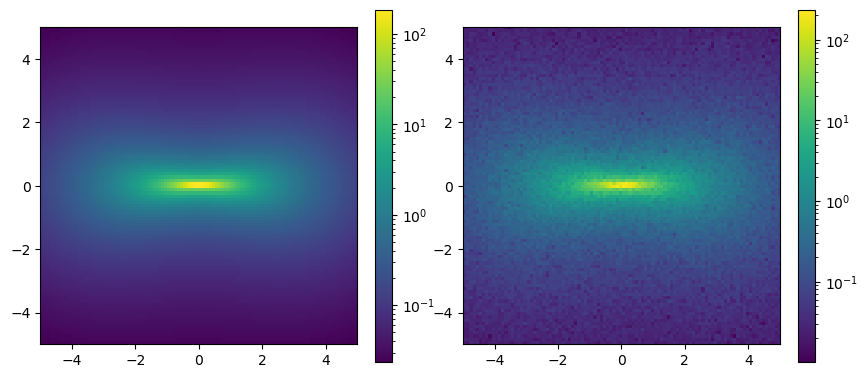

In [8]:
p_a_def = 0.
p_b_def = 0.
p_c_def = 0.088
p_d_def = 0.1
p6 = [p_a_def,p_b_def,p_c_def,p_d_def]
p_input_params.append(p6)

linear_incline_data, extents, size = create_dummy_image(e_k_def,e_d_def,p_a_def,p_b_def,p_c_def,p_d_def,q_a_def,q_b_def,q_c_def,q_d_def,
                                                        rho0_def,s_def,a_def,b_def,i_def,phi_def,theta_def,0.2)

In [9]:
from JAX_Deprojection import utils

numpyro.enable_validation(is_validate=True)

# create r array smallest smaller than grid biggest bigger with ~100 points
def model(rho_x, rho_y, rho_z, r, sigma_obs=None):
    #eps = 1e-12

    r_gp = jnp.linspace(jnp.min(r)-0.05,jnp.max(r)+0.5,1000)

    p0 = numpyro.sample('p0', dist.Uniform(0.001,1.)) # i.e. = p(0)
    p5 = numpyro.sample('p5', dist.Uniform(0.001,1.)) # i.e. = p(5)
    
    def linear_mean_function(r):
        return p0 + ((p5-p0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_p = numpyro.sample("sigma_p", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_p = numpyro.sample("length_scale_p", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_p = sigma_p**2 * kernels.ExpSquared(length_scale_p)
    gp_p = GaussianProcess(kernel_p, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    p_not_transformed = numpyro.sample("p_not_transformed", gp_p.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    p= numpyro.deterministic("p", jnp.clip(p_not_transformed+linear_mean_function(r_gp), min = 1e-10, max = 1.))
    interpolator = RegularGridInterpolator((r_gp,), p, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    p_final = interpolator(r)

    # Constant parameters
    q = numpyro.deterministic("q",numpyro.sample('q_sample', dist.Uniform(1e-10,1.)))
    e = 0.0
    rho0 = 1.0
    s = 1.0
    a = 2.0
    b = 4.0
    i = 0.0
    phi = 0.0
    theta = 0.0


    # Compute the density
    density = utils.rho(rho_x, rho_y, rho_z, e, e, 0., 0., 0., p_final, 0., 0., 0., q, rho0, s, a, b, i, phi, theta)

    sb = numpyro.deterministic("sb", jnp.sum(density, axis = 2))

    # Observation model
    numpyro.sample("sigma_obs", dist.TruncatedNormal(sb, 0.2 * sb,low = 1e-10), obs=sigma_obs)

In [10]:
def runsvi(adam,elbo,noisy_data,steps,rho_x,rho_y,rho_z,r):# Use AutoGuide for variational inference
    guide = AutoDelta(model)

    # Optimizer and inference
    optim = Adam(adam)
    svi = SVI(model, guide, optim, Trace_ELBO(elbo))
    key = jax.random.PRNGKey(42)

    results = svi.run(key, steps, rho_x,rho_y,rho_z,r, sigma_obs=noisy_data)

    return results, guide 

#maybe use svi step instead of svi run to use dynamic step number and prevent loss from going to infinity

In [11]:
#steps = 500
extent = extents[1]

x,y = jnp.meshgrid(jnp.linspace(-extent,extent,size),jnp.linspace(-extent,extent,size),indexing='ij')

x = x.flatten()
y = y.flatten()
grid_size = jnp.astype(jnp.sqrt(len(x)),jnp.int32)

rho_x,rho_y,rho_z = utils.create_grid(grid_size,jnp.max(x))
r = jnp.sqrt(rho_x**2 + rho_y**2 + rho_z**2)

r_gp = jnp.linspace(jnp.min(r)-0.05,jnp.max(r)+0.5,1000)

#results, guide = runsvi(0.1,1,noisy_data,steps,rho_x,rho_y,rho_z,r)

In [12]:
def p(r,p_a,p_b,p_c,p_d):
    p = p_a * r**3 + p_b * r**2 + p_c * r + p_d
    return p

def score_const(def_val,pred_val):
    return jnp.abs(def_val - pred_val)

def score_r(def_val,pred_val):
    return jnp.sqrt(jnp.sum((def_val - pred_val)**2)/len(def_val))

0.02 10 300


100%|██████████| 300/300 [01:53<00:00,  2.65it/s, init loss: 309197.5625, avg. loss [286-300]: -22917.0474]


0.02 10 600


100%|██████████| 600/600 [03:42<00:00,  2.69it/s, init loss: 309197.5625, avg. loss [571-600]: -22945.2085]


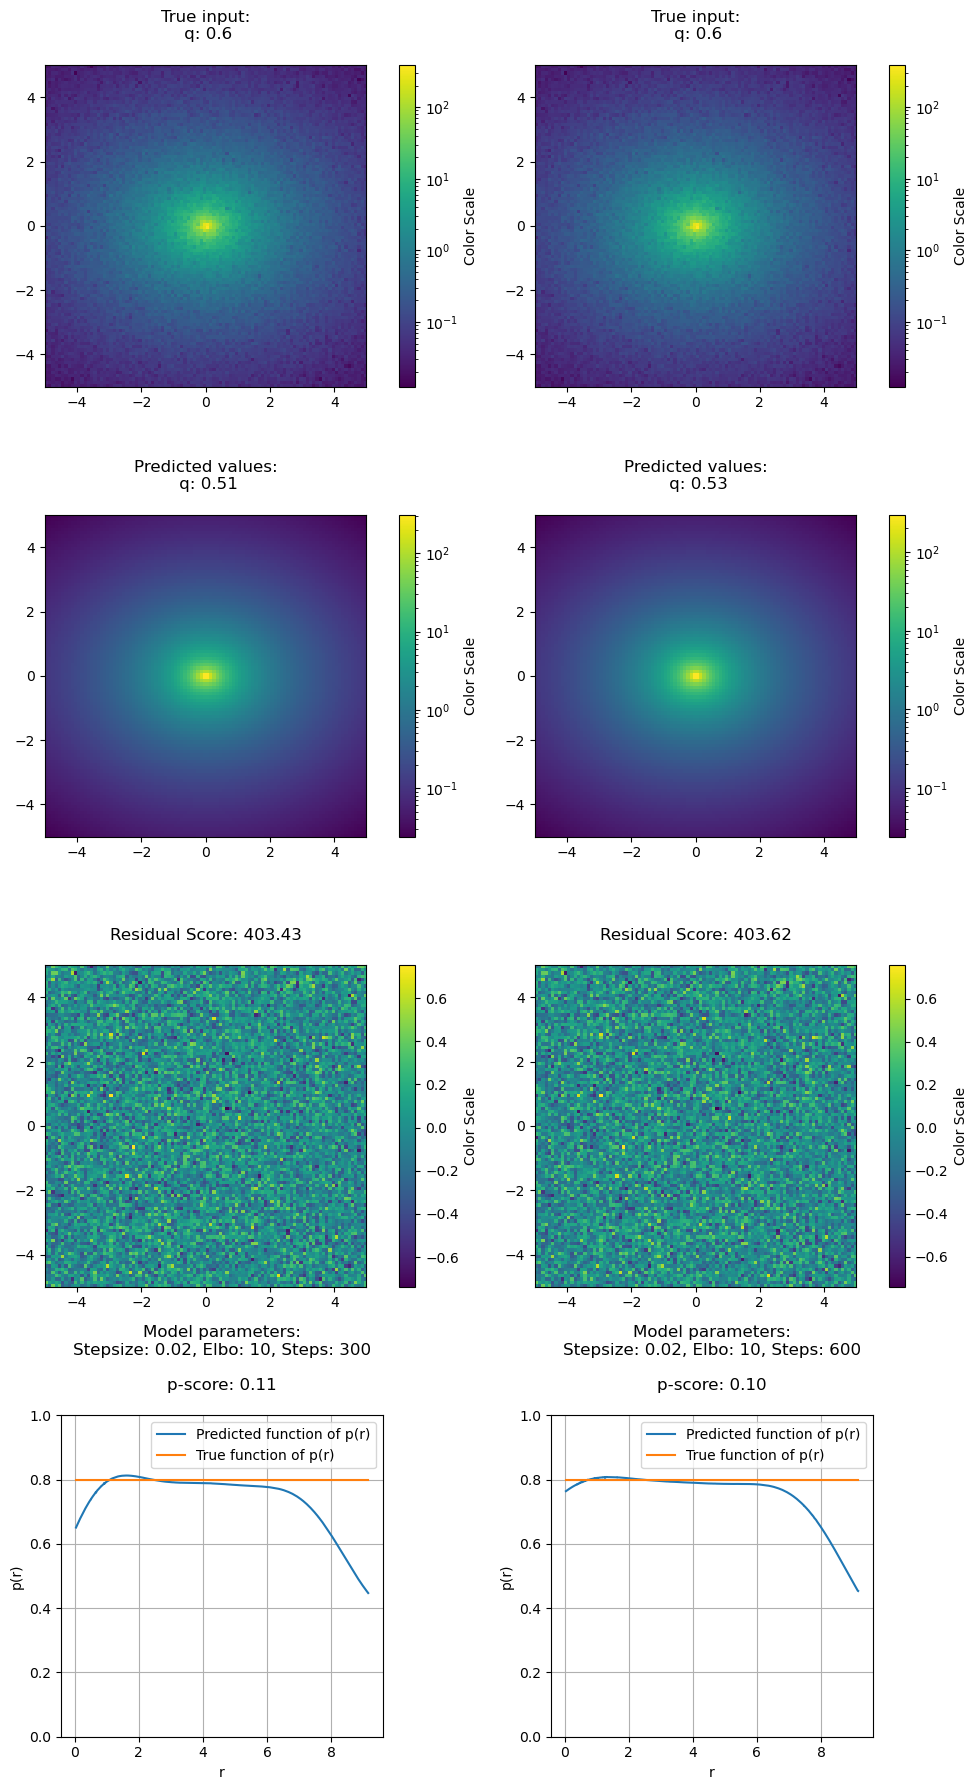

In [13]:
csv_results = []

adam_params = [0.02]
elbo_params = [10]
steps_param = [300,600]

input_data = [const_high_data] #[poly_extreme_data,poly_flat_data,const_low_data,const_high_data,linear_decline_data,linear_incline_data]
input_p = "const_high"

input_index = 3

model_name = "p(r)_q"

fig, axes = plt.subplots(4,2, figsize=(10,18))
for w in range(len(adam_params)):
    for j in range(len(elbo_params)):
        for k in range(len(steps_param)):
            for i in range(len(input_data)):
                print(adam_params[w],elbo_params[j],steps_param[k])
                results, guide = runsvi(adam_params[w],elbo_params[j],input_data[i],steps_param[k],rho_x,rho_y,rho_z,r)

                q_pred = results.params['q_sample_auto_loc']
                key = jax.random.PRNGKey(42)

                predictive = Predictive(guide, params=results.params, num_samples=1000)
                posterior_samples = predictive(key,rho_x,rho_y,rho_z,r)

                predictive = Predictive(model, posterior_samples, params=results.params, num_samples=1000)
                posterior_predictive_samples = predictive(key,rho_x,rho_y,rho_z,r)


                p_mean = posterior_predictive_samples['p'].mean(axis=0)
                p_std = posterior_predictive_samples['p'].std(axis=0)

                sb_mean = posterior_predictive_samples['sb'].mean(axis=0)
                sb_std = posterior_predictive_samples['sb'].std(axis=0)


                p1,p2,p3,p4 = p_input_params[input_index][0],p_input_params[input_index][1],p_input_params[input_index][2],p_input_params[input_index][3]
                
                q_score = float(score_const(q_d_def,q_pred))

                p_obs = p(r_gp,p1,p2,p3,p4)
            
                p_score = float(score_r(p_obs,p_mean))
                
                img_score = float(utils.ssd_score(input_data[i],sb_mean,sb_mean))
                total_score = img_score + p_score + q_score
                ph = None

                csv_entry = [model_name,input_p,ph,ph,adam_params[w],elbo_params[j],steps_param[k],q_d_def,q_pred,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,p_score,q_score,ph,img_score,total_score]
                csv_results.append(csv_entry)

                
                ax1 = axes[0,k]
                ax2 = axes[1,k]
                ax3 = axes[2,k]
                ax4 = axes[3,k]

                img1 = ax1.imshow(input_data[i].T, norm=colors.LogNorm(vmin=input_data[i].min(), vmax=input_data[i].max()), origin='lower',extent = extents)
                fig.colorbar(img1, ax=ax1, label='Color Scale',fraction = 0.05)
                ax1.set_title("True input:\n q: {}\n".format(q_d_def))
                ax1.set_anchor((0.6, 0.5))

                img2 = ax2.imshow(sb_mean.T, norm=colors.LogNorm(vmin=sb_mean.min(), vmax=sb_mean.max()), origin='lower',extent = extents)
                fig.colorbar(img2, ax=ax2, label='Color Scale',fraction = 0.05)
                ax2.set_title("Predicted values:\n q: {:.2f}\n".format(q_pred))
                ax2.set_anchor((0.6, 0.5))

                residual = (input_data[i] - sb_mean)/sb_mean
                img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
                fig.colorbar(img3, ax=ax3, label='Color Scale',fraction = 0.05)
                ax3.set_title("Residual Score: {:.2f}\n".format(img_score))
                ax3.set_anchor((0.6, 0.5))
                
                ax4.plot(r_gp, p_mean, label="Predicted function of p(r)")
                ax4.plot(r_gp, p_obs, label="True function of p(r)")
                ax4.legend()
                ax4.set_xlabel('r')
                ax4.set_ylabel('p(r)')
                ax4.grid(True)
                ax4.set_ylim([0,1])
                ax4.set_title("Model parameters:\nStepsize: {}, Elbo: {}, Steps: {}\n\np-score: {:.2f}\n".format(adam_params[w],elbo_params[j],steps_param[k],p_score))
                asp = np.diff(ax4.get_xlim())[0] / np.diff(ax4.get_ylim())[0]
                ax4.set_aspect(asp)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("Z:\\Uni\Master_Astronomy\\GitHub\\JAX_deprojection\\SVI_notebooks\\p1\\plots\\"+input_p+"_"+model_name+".png")  
plt.show()
            

## p(r) + e

0.02 10 300


100%|██████████| 300/300 [02:08<00:00,  2.33it/s, init loss: 7234302.5000, avg. loss [286-300]: -21813.1974]


0.02 10 600


100%|██████████| 600/600 [04:06<00:00,  2.44it/s, init loss: 7234302.5000, avg. loss [571-600]: -22796.4578]


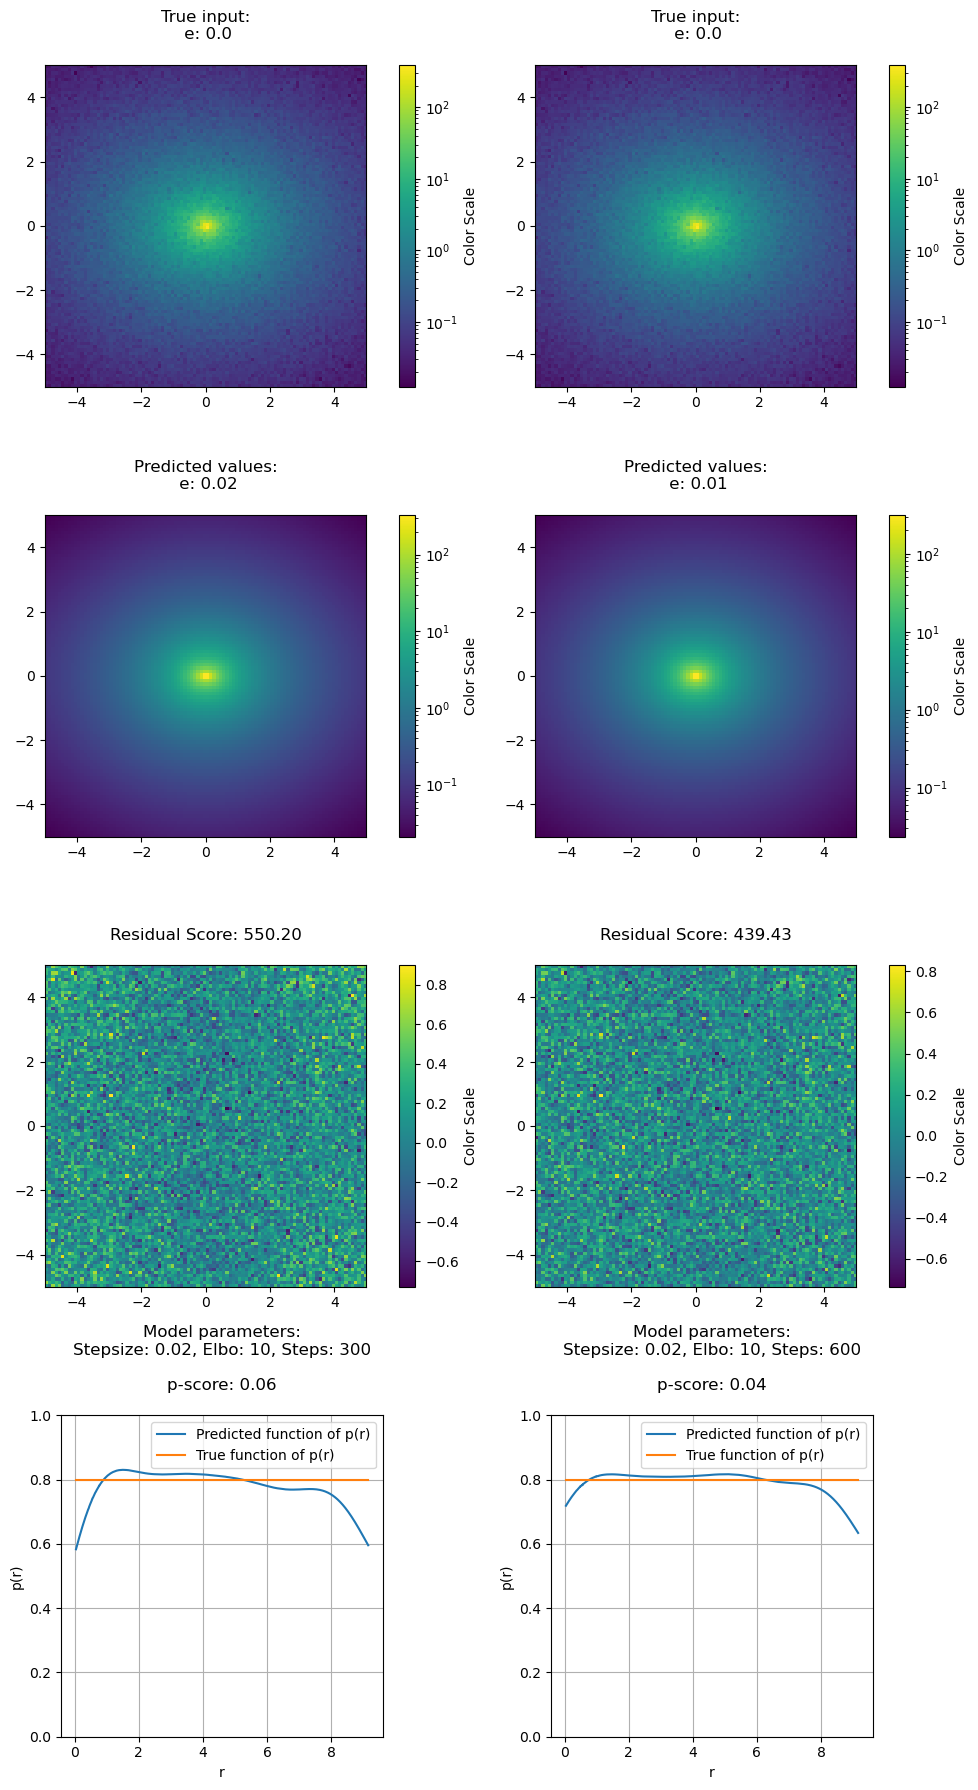

In [14]:
def model(rho_x, rho_y, rho_z, r, sigma_obs=None):
    #eps = 1e-12

    r_gp = jnp.linspace(jnp.min(r)-0.05,jnp.max(r)+0.5,1000)

    p0 = numpyro.sample('p0', dist.Uniform(0.001,1.)) # i.e. = p(0)
    p5 = numpyro.sample('p5', dist.Uniform(0.001,1.)) # i.e. = p(5)
    
    def linear_mean_function(r):
        return p0 + ((p5-p0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_p = numpyro.sample("sigma_p", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_p = numpyro.sample("length_scale_p", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_p = sigma_p**2 * kernels.ExpSquared(length_scale_p)
    gp_p = GaussianProcess(kernel_p, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    p_not_transformed = numpyro.sample("p_not_transformed", gp_p.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    p= numpyro.deterministic("p", jnp.clip(p_not_transformed+linear_mean_function(r_gp), min = 1e-10, max = 1.))
    interpolator = RegularGridInterpolator((r_gp,), p, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    p_final = interpolator(r)

    # Constant parameters
    q = 0.6
    e = numpyro.deterministic("e",numpyro.sample('e_sample', dist.Uniform(-1.,1.)))
    rho0 = 1.0
    s = 1.0
    a = 2.0
    b = 4.0
    i = 0.0
    phi = 0.0
    theta = 0.0


    # Compute the density
    density = utils.rho(rho_x, rho_y, rho_z, e, e, 0., 0., 0., p_final, 0., 0., 0., q, rho0, s, a, b, i, phi, theta)

    sb = numpyro.deterministic("sb", jnp.sum(density, axis = 2))

    # Observation model
    numpyro.sample("sigma_obs", dist.TruncatedNormal(sb, 0.2 * sb,low = 1e-10), obs=sigma_obs)


model_name = "p(r)_e"

fig, axes = plt.subplots(4,2, figsize=(10,18))
for w in range(len(adam_params)):
    for j in range(len(elbo_params)):
        for k in range(len(steps_param)):
            for i in range(len(input_data)):
                print(adam_params[w],elbo_params[j],steps_param[k])
                results, guide = runsvi(adam_params[w],elbo_params[j],input_data[i],steps_param[k],rho_x,rho_y,rho_z,r)

                e_pred = results.params['e_sample_auto_loc']
                key = jax.random.PRNGKey(42)

                predictive = Predictive(guide, params=results.params, num_samples=1000)
                posterior_samples = predictive(key,rho_x,rho_y,rho_z,r)

                predictive = Predictive(model, posterior_samples, params=results.params, num_samples=1000)
                posterior_predictive_samples = predictive(key,rho_x,rho_y,rho_z,r)


                p_mean = posterior_predictive_samples['p'].mean(axis=0)
                p_std = posterior_predictive_samples['p'].std(axis=0)

                sb_mean = posterior_predictive_samples['sb'].mean(axis=0)
                sb_std = posterior_predictive_samples['sb'].std(axis=0)


                p1,p2,p3,p4 = p_input_params[input_index][0],p_input_params[input_index][1],p_input_params[input_index][2],p_input_params[input_index][3]
                
                e_score = float(score_const(e_d_def,e_pred))

                p_obs = p(r_gp,p1,p2,p3,p4)
            
                p_score = float(score_r(p_obs,p_mean))
                
                img_score = float(utils.ssd_score(input_data[i],sb_mean,sb_mean))
                total_score = img_score + p_score + e_score
                ph = None

                csv_entry = [model_name,input_p,ph,ph,adam_params[w],elbo_params[j],steps_param[k],ph,ph,e_d_def,e_score,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,p_score,ph,e_score,img_score,total_score]
                csv_results.append(csv_entry)

                
                ax1 = axes[0,k]
                ax2 = axes[1,k]
                ax3 = axes[2,k]
                ax4 = axes[3,k]

                img1 = ax1.imshow(input_data[i].T, norm=colors.LogNorm(vmin=input_data[i].min(), vmax=input_data[i].max()), origin='lower',extent = extents)
                fig.colorbar(img1, ax=ax1, label='Color Scale',fraction = 0.05)
                ax1.set_title("True input:\n e: {}\n".format(e_d_def))
                ax1.set_anchor((0.6, 0.5))

                img2 = ax2.imshow(sb_mean.T, norm=colors.LogNorm(vmin=sb_mean.min(), vmax=sb_mean.max()), origin='lower',extent = extents)
                fig.colorbar(img2, ax=ax2, label='Color Scale',fraction = 0.05)
                ax2.set_title("Predicted values:\n e: {:.2f}\n".format(e_pred))
                ax2.set_anchor((0.6, 0.5))

                residual = (input_data[i] - sb_mean)/sb_mean
                img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
                fig.colorbar(img3, ax=ax3, label='Color Scale',fraction = 0.05)
                ax3.set_title("Residual Score: {:.2f}\n".format(img_score))
                ax3.set_anchor((0.6, 0.5))
                
                ax4.plot(r_gp, p_mean, label="Predicted function of p(r)")
                ax4.plot(r_gp, p_obs, label="True function of p(r)")
                ax4.legend()
                ax4.set_xlabel('r')
                ax4.set_ylabel('p(r)')
                ax4.grid(True)
                ax4.set_ylim([0,1])
                ax4.set_title("Model parameters:\nStepsize: {}, Elbo: {}, Steps: {}\n\np-score: {:.2f}\n".format(adam_params[w],elbo_params[j],steps_param[k],p_score))
                asp = np.diff(ax4.get_xlim())[0] / np.diff(ax4.get_ylim())[0]
                ax4.set_aspect(asp)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("Z:\\Uni\Master_Astronomy\\GitHub\\JAX_deprojection\\SVI_notebooks\\p1\\plots\\"+input_p+"_"+model_name+".png")  
plt.show()

## p(r) + rho0

0.02 10 300


100%|██████████| 300/300 [01:51<00:00,  2.68it/s, init loss: 1516181.6250, avg. loss [286-300]: -16424.7332]


0.02 10 600


100%|██████████| 600/600 [03:38<00:00,  2.75it/s, init loss: 1516181.6250, avg. loss [571-600]: -20258.0615]


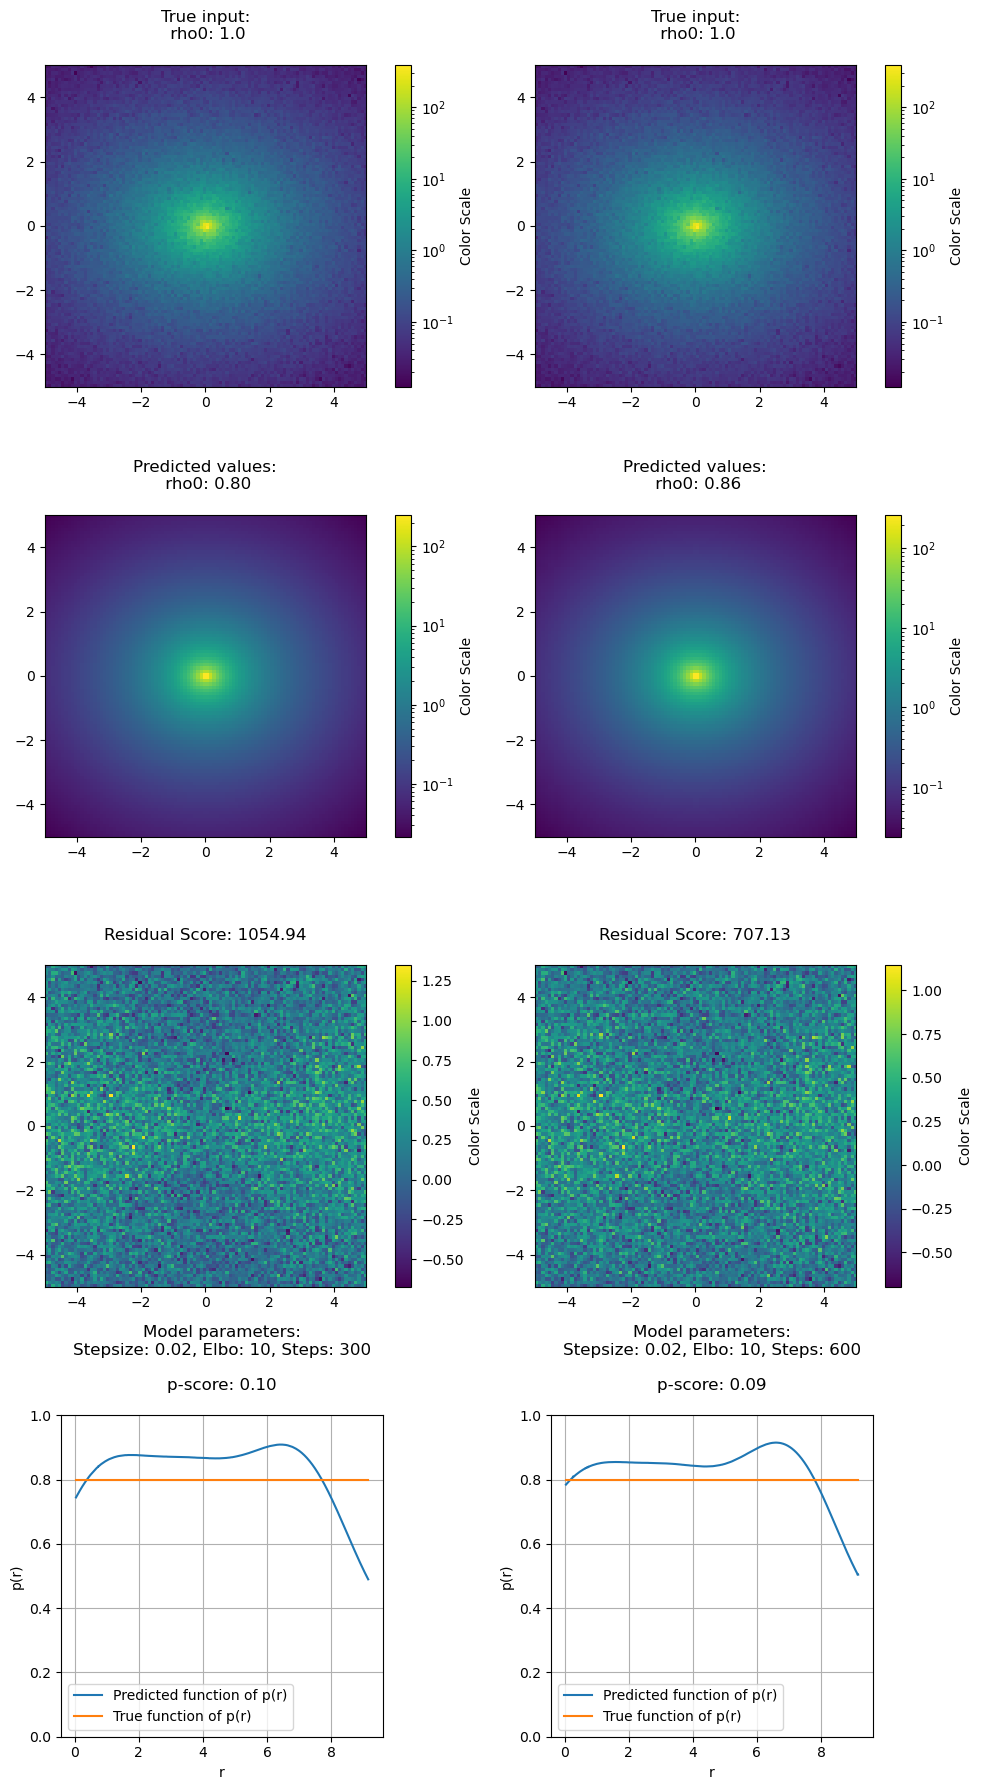

In [15]:
def model(rho_x, rho_y, rho_z, r, sigma_obs=None):
    #eps = 1e-12

    r_gp = jnp.linspace(jnp.min(r)-0.05,jnp.max(r)+0.5,1000)

    p0 = numpyro.sample('p0', dist.Uniform(0.001,1.)) # i.e. = p(0)
    p5 = numpyro.sample('p5', dist.Uniform(0.001,1.)) # i.e. = p(5)
    
    def linear_mean_function(r):
        return p0 + ((p5-p0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_p = numpyro.sample("sigma_p", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_p = numpyro.sample("length_scale_p", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_p = sigma_p**2 * kernels.ExpSquared(length_scale_p)
    gp_p = GaussianProcess(kernel_p, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    p_not_transformed = numpyro.sample("p_not_transformed", gp_p.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    p= numpyro.deterministic("p", jnp.clip(p_not_transformed+linear_mean_function(r_gp), min = 1e-10, max = 1.))
    interpolator = RegularGridInterpolator((r_gp,), p, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    p_final = interpolator(r)

    # Constant parameters
    q = 0.6
    e = 0.0
    rho0 = numpyro.deterministic("rho0",numpyro.sample('rho0_sample', dist.Uniform(1e-10,1.)))
    s = 1.0
    a = 2.0
    b = 4.0
    i = 0.0
    phi = 0.0
    theta = 0.0


    # Compute the density
    density = utils.rho(rho_x, rho_y, rho_z, e, e, 0., 0., 0., p_final, 0., 0., 0., q, rho0, s, a, b, i, phi, theta)

    sb = numpyro.deterministic("sb", jnp.sum(density, axis = 2))

    # Observation model
    numpyro.sample("sigma_obs", dist.TruncatedNormal(sb, 0.2 * sb,low = 1e-10), obs=sigma_obs)


model_name = "p(r)_rho0"

fig, axes = plt.subplots(4,2, figsize=(10,18))
for w in range(len(adam_params)):
    for j in range(len(elbo_params)):
        for k in range(len(steps_param)):
            for i in range(len(input_data)):
                print(adam_params[w],elbo_params[j],steps_param[k])
                results, guide = runsvi(adam_params[w],elbo_params[j],input_data[i],steps_param[k],rho_x,rho_y,rho_z,r)

                rho0_pred = results.params['rho0_sample_auto_loc']
                key = jax.random.PRNGKey(42)

                predictive = Predictive(guide, params=results.params, num_samples=1000)
                posterior_samples = predictive(key,rho_x,rho_y,rho_z,r)

                predictive = Predictive(model, posterior_samples, params=results.params, num_samples=1000)
                posterior_predictive_samples = predictive(key,rho_x,rho_y,rho_z,r)


                p_mean = posterior_predictive_samples['p'].mean(axis=0)
                p_std = posterior_predictive_samples['p'].std(axis=0)

                sb_mean = posterior_predictive_samples['sb'].mean(axis=0)
                sb_std = posterior_predictive_samples['sb'].std(axis=0)


                p1,p2,p3,p4 = p_input_params[input_index][0],p_input_params[input_index][1],p_input_params[input_index][2],p_input_params[input_index][3]
                
                rho0_score = float(score_const(rho0_def,rho0_pred))

                p_obs = p(r_gp,p1,p2,p3,p4)
            
                p_score = float(score_r(p_obs,p_mean))
                
                img_score = float(utils.ssd_score(input_data[i],sb_mean,sb_mean))
                total_score = img_score + p_score + rho0_score
                ph = None

                csv_entry = [model_name,input_p,ph,ph,adam_params[w],elbo_params[j],steps_param[k],ph,ph,ph,ph,rho0_def,rho0_pred,rho0_score,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,p_score,ph,ph,img_score,total_score]
                csv_results.append(csv_entry)

                
                ax1 = axes[0,k]
                ax2 = axes[1,k]
                ax3 = axes[2,k]
                ax4 = axes[3,k]

                img1 = ax1.imshow(input_data[i].T, norm=colors.LogNorm(vmin=input_data[i].min(), vmax=input_data[i].max()), origin='lower',extent = extents)
                fig.colorbar(img1, ax=ax1, label='Color Scale',fraction = 0.05)
                ax1.set_title("True input:\n rho0: {}\n".format(rho0_def))
                ax1.set_anchor((0.6, 0.5))

                img2 = ax2.imshow(sb_mean.T, norm=colors.LogNorm(vmin=sb_mean.min(), vmax=sb_mean.max()), origin='lower',extent = extents)
                fig.colorbar(img2, ax=ax2, label='Color Scale',fraction = 0.05)
                ax2.set_title("Predicted values:\n rho0: {:.2f}\n".format(rho0_pred))
                ax2.set_anchor((0.6, 0.5))

                residual = (input_data[i] - sb_mean)/sb_mean
                img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
                fig.colorbar(img3, ax=ax3, label='Color Scale',fraction = 0.05)
                ax3.set_title("Residual Score: {:.2f}\n".format(img_score))
                ax3.set_anchor((0.6, 0.5))
                
                ax4.plot(r_gp, p_mean, label="Predicted function of p(r)")
                ax4.plot(r_gp, p_obs, label="True function of p(r)")
                ax4.legend()
                ax4.set_xlabel('r')
                ax4.set_ylabel('p(r)')
                ax4.grid(True)
                ax4.set_ylim([0,1])
                ax4.set_title("Model parameters:\nStepsize: {}, Elbo: {}, Steps: {}\n\np-score: {:.2f}\n".format(adam_params[w],elbo_params[j],steps_param[k],p_score))
                asp = np.diff(ax4.get_xlim())[0] / np.diff(ax4.get_ylim())[0]
                ax4.set_aspect(asp)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("Z:\\Uni\Master_Astronomy\\GitHub\\JAX_deprojection\\SVI_notebooks\\p1\\plots\\"+input_p+"_"+model_name+".png")  
plt.show()

## p(r) + s

0.02 10 300


100%|██████████| 300/300 [01:50<00:00,  2.71it/s, init loss: 119437.3438, avg. loss [286-300]: -22879.5471]


0.02 10 600


100%|██████████| 600/600 [03:36<00:00,  2.77it/s, init loss: 119437.3438, avg. loss [571-600]: -22947.2951]


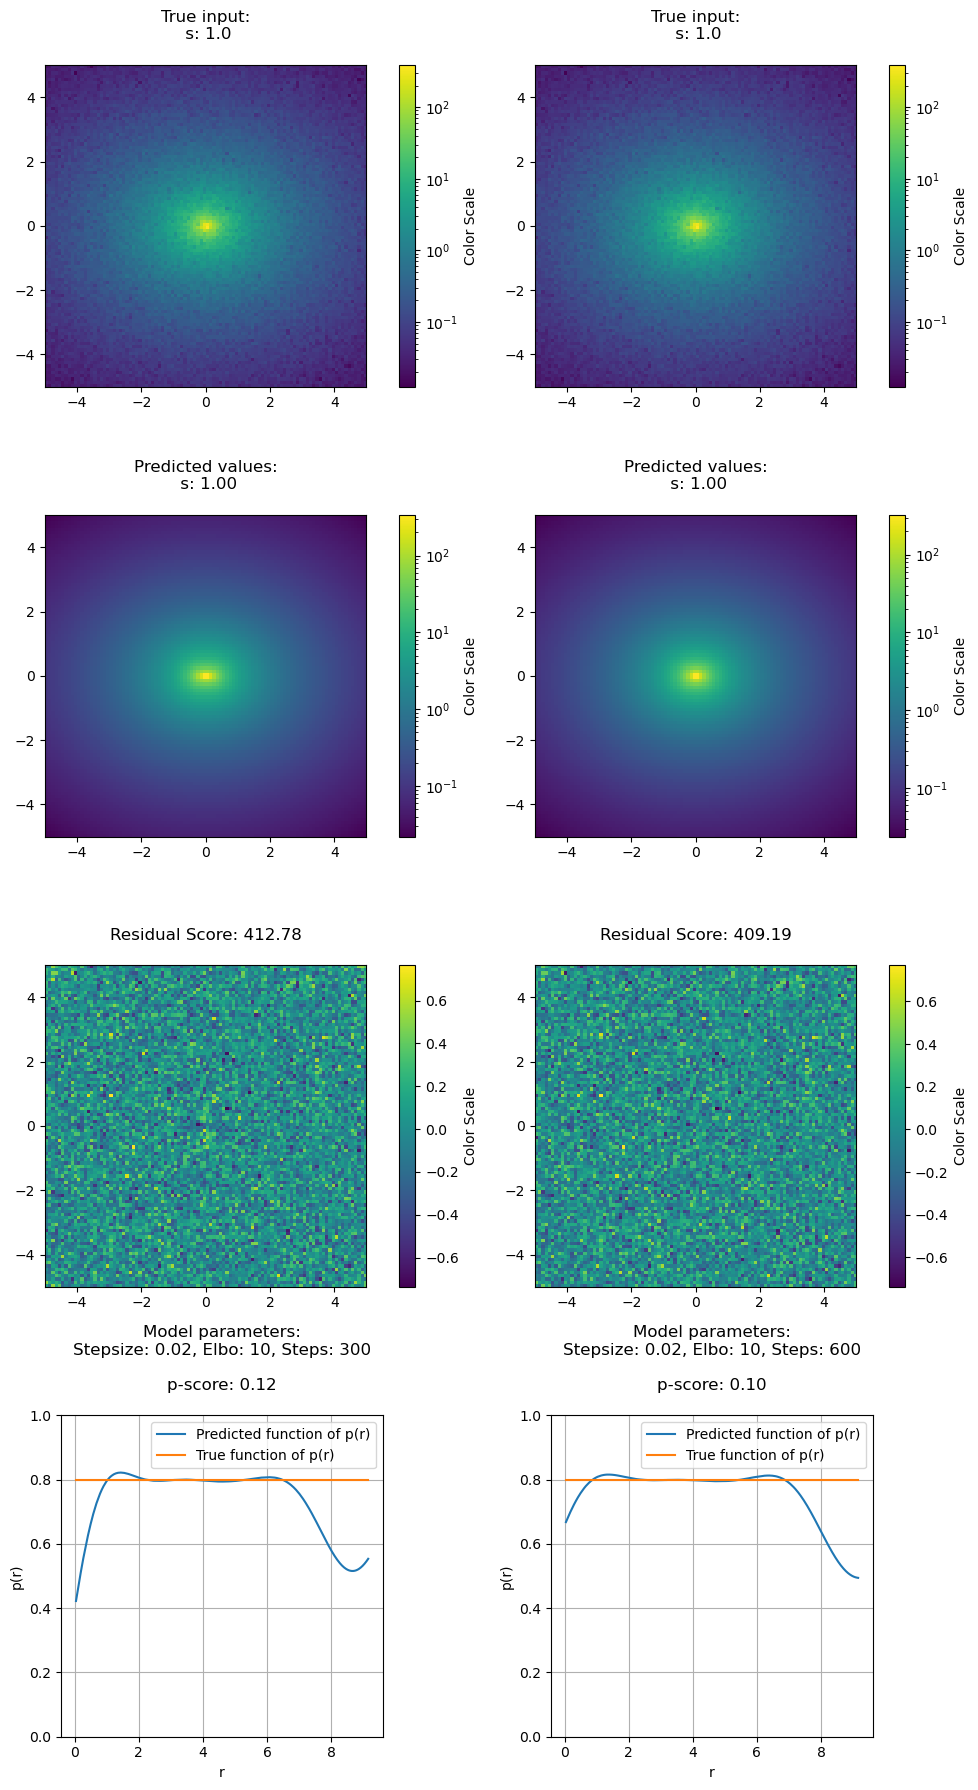

In [16]:
def model(rho_x, rho_y, rho_z, r, sigma_obs=None):
    #eps = 1e-12

    r_gp = jnp.linspace(jnp.min(r)-0.05,jnp.max(r)+0.5,1000)

    p0 = numpyro.sample('p0', dist.Uniform(0.001,1.)) # i.e. = p(0)
    p5 = numpyro.sample('p5', dist.Uniform(0.001,1.)) # i.e. = p(5)
    
    def linear_mean_function(r):
        return p0 + ((p5-p0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_p = numpyro.sample("sigma_p", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_p = numpyro.sample("length_scale_p", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_p = sigma_p**2 * kernels.ExpSquared(length_scale_p)
    gp_p = GaussianProcess(kernel_p, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    p_not_transformed = numpyro.sample("p_not_transformed", gp_p.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    p= numpyro.deterministic("p", jnp.clip(p_not_transformed+linear_mean_function(r_gp), min = 1e-10, max = 1.))
    interpolator = RegularGridInterpolator((r_gp,), p, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    p_final = interpolator(r)

    # Constant parameters
    q = 0.6
    e = 0.0
    rho0 = 1.0
    s = numpyro.deterministic("s",numpyro.sample('s_sample', dist.Uniform(0.2,5.)))
    a = 2.0
    b = 4.0
    i = 0.0
    phi = 0.0
    theta = 0.0


    # Compute the density
    density = utils.rho(rho_x, rho_y, rho_z, e, e, 0., 0., 0., p_final, 0., 0., 0., q, rho0, s, a, b, i, phi, theta)

    sb = numpyro.deterministic("sb", jnp.sum(density, axis = 2))

    # Observation model
    numpyro.sample("sigma_obs", dist.TruncatedNormal(sb, 0.2 * sb,low = 1e-10), obs=sigma_obs)

model_name = "p(r)_s"

fig, axes = plt.subplots(4,2, figsize=(10,18))
for w in range(len(adam_params)):
    for j in range(len(elbo_params)):
        for k in range(len(steps_param)):
            for i in range(len(input_data)):
                print(adam_params[w],elbo_params[j],steps_param[k])
                results, guide = runsvi(adam_params[w],elbo_params[j],input_data[i],steps_param[k],rho_x,rho_y,rho_z,r)

                s_pred = results.params['s_sample_auto_loc']
                key = jax.random.PRNGKey(42)

                predictive = Predictive(guide, params=results.params, num_samples=1000)
                posterior_samples = predictive(key,rho_x,rho_y,rho_z,r)

                predictive = Predictive(model, posterior_samples, params=results.params, num_samples=1000)
                posterior_predictive_samples = predictive(key,rho_x,rho_y,rho_z,r)


                p_mean = posterior_predictive_samples['p'].mean(axis=0)
                p_std = posterior_predictive_samples['p'].std(axis=0)

                sb_mean = posterior_predictive_samples['sb'].mean(axis=0)
                sb_std = posterior_predictive_samples['sb'].std(axis=0)


                p1,p2,p3,p4 = p_input_params[input_index][0],p_input_params[input_index][1],p_input_params[input_index][2],p_input_params[input_index][3]
                
                s_score = float(score_const(s_def,s_pred))

                p_obs = p(r_gp,p1,p2,p3,p4)
            
                p_score = float(score_r(p_obs,p_mean))
                
                img_score = float(utils.ssd_score(input_data[i],sb_mean,sb_mean))
                total_score = img_score + p_score + s_score
                ph = None

                csv_entry = [model_name,input_p,ph,ph,adam_params[w],elbo_params[j],steps_param[k],ph,ph,ph,ph,ph,ph,ph,s_def,s_pred,s_score,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,p_score,ph,ph,img_score,total_score]
                csv_results.append(csv_entry)

                
                ax1 = axes[0,k]
                ax2 = axes[1,k]
                ax3 = axes[2,k]
                ax4 = axes[3,k]

                img1 = ax1.imshow(input_data[i].T, norm=colors.LogNorm(vmin=input_data[i].min(), vmax=input_data[i].max()), origin='lower',extent = extents)
                fig.colorbar(img1, ax=ax1, label='Color Scale',fraction = 0.05)
                ax1.set_title("True input:\n s: {}\n".format(s_def))
                ax1.set_anchor((0.6, 0.5))

                img2 = ax2.imshow(sb_mean.T, norm=colors.LogNorm(vmin=sb_mean.min(), vmax=sb_mean.max()), origin='lower',extent = extents)
                fig.colorbar(img2, ax=ax2, label='Color Scale',fraction = 0.05)
                ax2.set_title("Predicted values:\n s: {:.2f}\n".format(s_pred))
                ax2.set_anchor((0.6, 0.5))

                residual = (input_data[i] - sb_mean)/sb_mean
                img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
                fig.colorbar(img3, ax=ax3, label='Color Scale',fraction = 0.05)
                ax3.set_title("Residual Score: {:.2f}\n".format(img_score))
                ax3.set_anchor((0.6, 0.5))
                
                ax4.plot(r_gp, p_mean, label="Predicted function of p(r)")
                ax4.plot(r_gp, p_obs, label="True function of p(r)")
                ax4.legend()
                ax4.set_xlabel('r')
                ax4.set_ylabel('p(r)')
                ax4.grid(True)
                ax4.set_ylim([0,1])
                ax4.set_title("Model parameters:\nStepsize: {}, Elbo: {}, Steps: {}\n\np-score: {:.2f}\n".format(adam_params[w],elbo_params[j],steps_param[k],p_score))
                asp = np.diff(ax4.get_xlim())[0] / np.diff(ax4.get_ylim())[0]
                ax4.set_aspect(asp)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("Z:\\Uni\Master_Astronomy\\GitHub\\JAX_deprojection\\SVI_notebooks\\p1\\plots\\"+input_p+"_"+model_name+".png")  
plt.show()

## p(r) + a

0.02 10 300


100%|██████████| 300/300 [01:45<00:00,  2.85it/s, init loss: 215045.0156, avg. loss [286-300]: -22879.7788]


0.02 10 600


100%|██████████| 600/600 [03:23<00:00,  2.94it/s, init loss: 215045.0156, avg. loss [571-600]: -22953.2867]


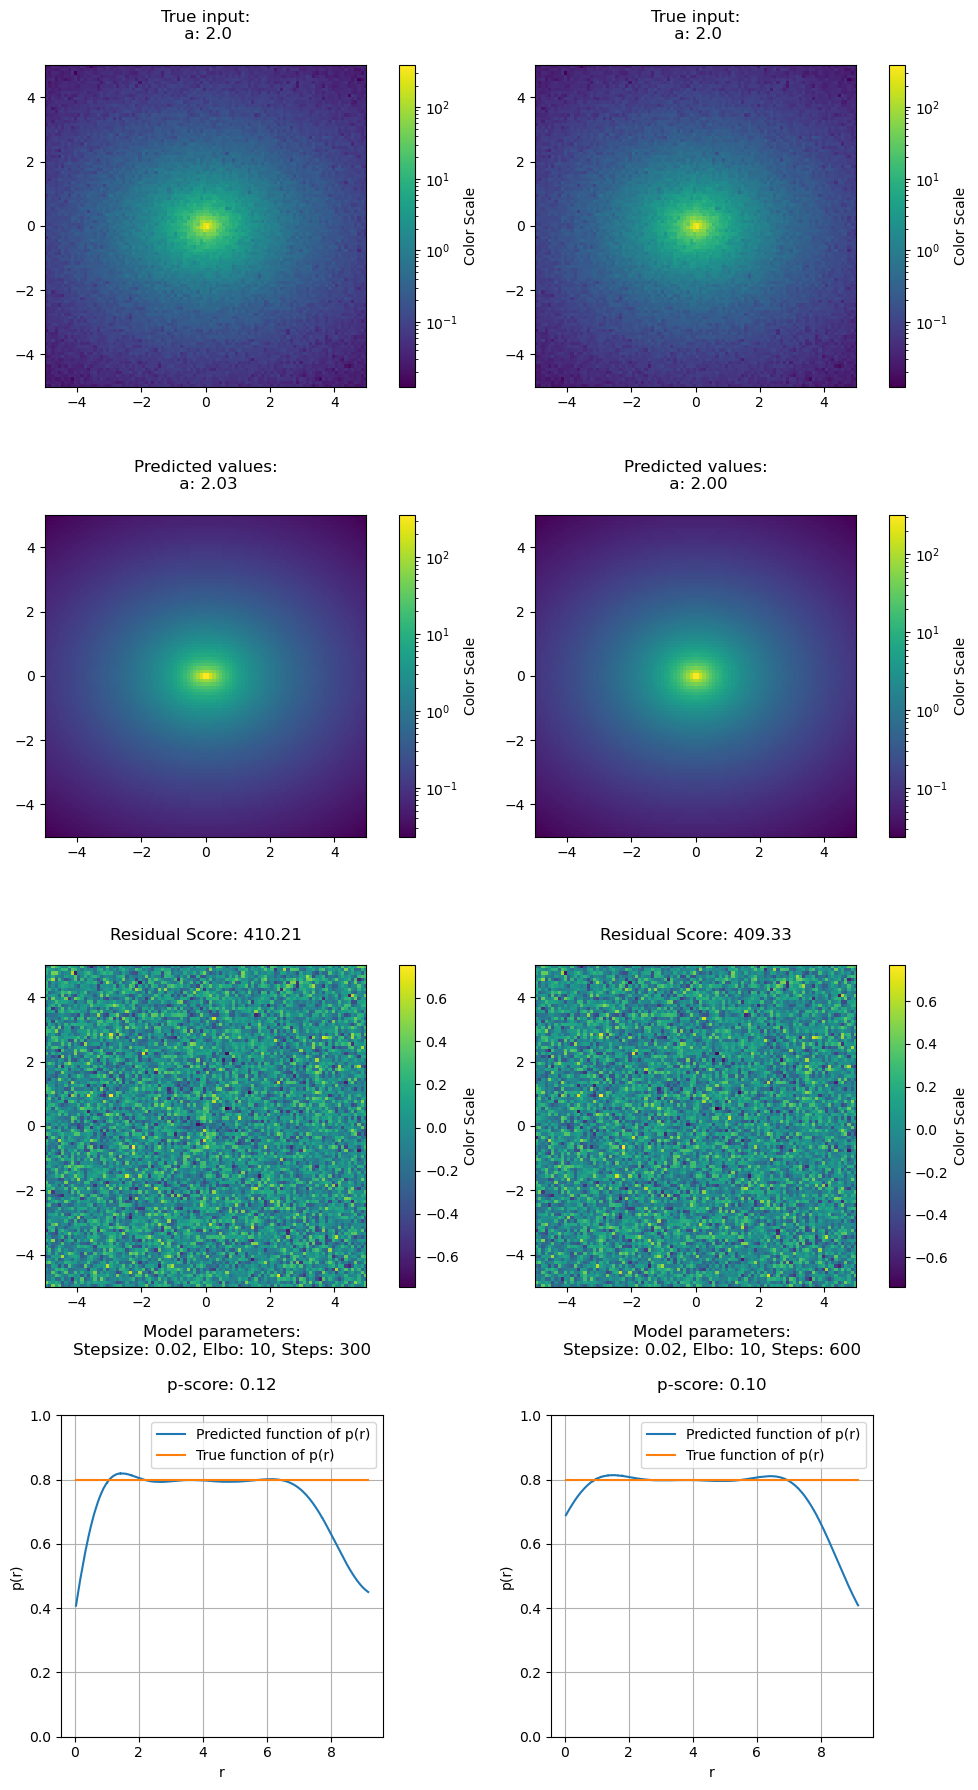

In [17]:
def model(rho_x, rho_y, rho_z, r, sigma_obs=None):
    #eps = 1e-12

    r_gp = jnp.linspace(jnp.min(r)-0.05,jnp.max(r)+0.5,1000)

    p0 = numpyro.sample('p0', dist.Uniform(0.001,1.)) # i.e. = p(0)
    p5 = numpyro.sample('p5', dist.Uniform(0.001,1.)) # i.e. = p(5)
    
    def linear_mean_function(r):
        return p0 + ((p5-p0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_p = numpyro.sample("sigma_p", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_p = numpyro.sample("length_scale_p", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_p = sigma_p**2 * kernels.ExpSquared(length_scale_p)
    gp_p = GaussianProcess(kernel_p, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    p_not_transformed = numpyro.sample("p_not_transformed", gp_p.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    p= numpyro.deterministic("p", jnp.clip(p_not_transformed+linear_mean_function(r_gp), min = 1e-10, max = 1.))
    interpolator = RegularGridInterpolator((r_gp,), p, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    p_final = interpolator(r)

    # Constant parameters
    q = 0.6
    e = 0.0
    rho0 = 1.0
    s = 1.0
    a = numpyro.deterministic("a",numpyro.sample('a_sample', dist.Uniform(1.,5.)))
    b = 4.0
    i = 0.0
    phi = 0.0
    theta = 0.0


    # Compute the density
    density = utils.rho(rho_x, rho_y, rho_z, e, e, 0., 0., 0., p_final, 0., 0., 0., q, rho0, s, a, b, i, phi, theta)

    sb = numpyro.deterministic("sb", jnp.sum(density, axis = 2))

    # Observation model
    numpyro.sample("sigma_obs", dist.TruncatedNormal(sb, 0.2 * sb,low = 1e-10), obs=sigma_obs)

model_name = "p(r)_a"

fig, axes = plt.subplots(4,2, figsize=(10,18))
for w in range(len(adam_params)):
    for j in range(len(elbo_params)):
        for k in range(len(steps_param)):
            for i in range(len(input_data)):
                print(adam_params[w],elbo_params[j],steps_param[k])
                results, guide = runsvi(adam_params[w],elbo_params[j],input_data[i],steps_param[k],rho_x,rho_y,rho_z,r)

                a_pred = results.params['a_sample_auto_loc']
                key = jax.random.PRNGKey(42)

                predictive = Predictive(guide, params=results.params, num_samples=1000)
                posterior_samples = predictive(key,rho_x,rho_y,rho_z,r)

                predictive = Predictive(model, posterior_samples, params=results.params, num_samples=1000)
                posterior_predictive_samples = predictive(key,rho_x,rho_y,rho_z,r)


                p_mean = posterior_predictive_samples['p'].mean(axis=0)
                p_std = posterior_predictive_samples['p'].std(axis=0)

                sb_mean = posterior_predictive_samples['sb'].mean(axis=0)
                sb_std = posterior_predictive_samples['sb'].std(axis=0)


                p1,p2,p3,p4 = p_input_params[input_index][0],p_input_params[input_index][1],p_input_params[input_index][2],p_input_params[input_index][3]
                
                a_score = float(score_const(a_def,a_pred))

                p_obs = p(r_gp,p1,p2,p3,p4)
            
                p_score = float(score_r(p_obs,p_mean))
                
                img_score = float(utils.ssd_score(input_data[i],sb_mean,sb_mean))
                total_score = img_score + p_score + a_score
                ph = None

                csv_entry = [model_name,input_p,ph,ph,adam_params[w],elbo_params[j],steps_param[k],ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,
                             a_def,a_pred,a_score,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,p_score,ph,ph,img_score,total_score]
                csv_results.append(csv_entry)

                
                ax1 = axes[0,k]
                ax2 = axes[1,k]
                ax3 = axes[2,k]
                ax4 = axes[3,k]

                img1 = ax1.imshow(input_data[i].T, norm=colors.LogNorm(vmin=input_data[i].min(), vmax=input_data[i].max()), origin='lower',extent = extents)
                fig.colorbar(img1, ax=ax1, label='Color Scale',fraction = 0.05)
                ax1.set_title("True input:\n a: {}\n".format(a_def))
                ax1.set_anchor((0.6, 0.5))

                img2 = ax2.imshow(sb_mean.T, norm=colors.LogNorm(vmin=sb_mean.min(), vmax=sb_mean.max()), origin='lower',extent = extents)
                fig.colorbar(img2, ax=ax2, label='Color Scale',fraction = 0.05)
                ax2.set_title("Predicted values:\n a: {:.2f}\n".format(a_pred))
                ax2.set_anchor((0.6, 0.5))

                residual = (input_data[i] - sb_mean)/sb_mean
                img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
                fig.colorbar(img3, ax=ax3, label='Color Scale',fraction = 0.05)
                ax3.set_title("Residual Score: {:.2f}\n".format(img_score))
                ax3.set_anchor((0.6, 0.5))
                
                ax4.plot(r_gp, p_mean, label="Predicted function of p(r)")
                ax4.plot(r_gp, p_obs, label="True function of p(r)")
                ax4.legend()
                ax4.set_xlabel('r')
                ax4.set_ylabel('p(r)')
                ax4.grid(True)
                ax4.set_ylim([0,1])
                ax4.set_title("Model parameters:\nStepsize: {}, Elbo: {}, Steps: {}\n\np-score: {:.2f}\n".format(adam_params[w],elbo_params[j],steps_param[k],p_score))
                asp = np.diff(ax4.get_xlim())[0] / np.diff(ax4.get_ylim())[0]
                ax4.set_aspect(asp)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("Z:\\Uni\Master_Astronomy\\GitHub\\JAX_deprojection\\SVI_notebooks\\p1\\plots\\"+input_p+"_"+model_name+".png")  
plt.show()

## p(r) + b

0.02 10 300


100%|██████████| 300/300 [01:42<00:00,  2.94it/s, init loss: 23393.0898, avg. loss [286-300]: -22948.2538]


0.02 10 600


100%|██████████| 600/600 [03:19<00:00,  3.00it/s, init loss: 23393.0898, avg. loss [571-600]: -22967.1225]


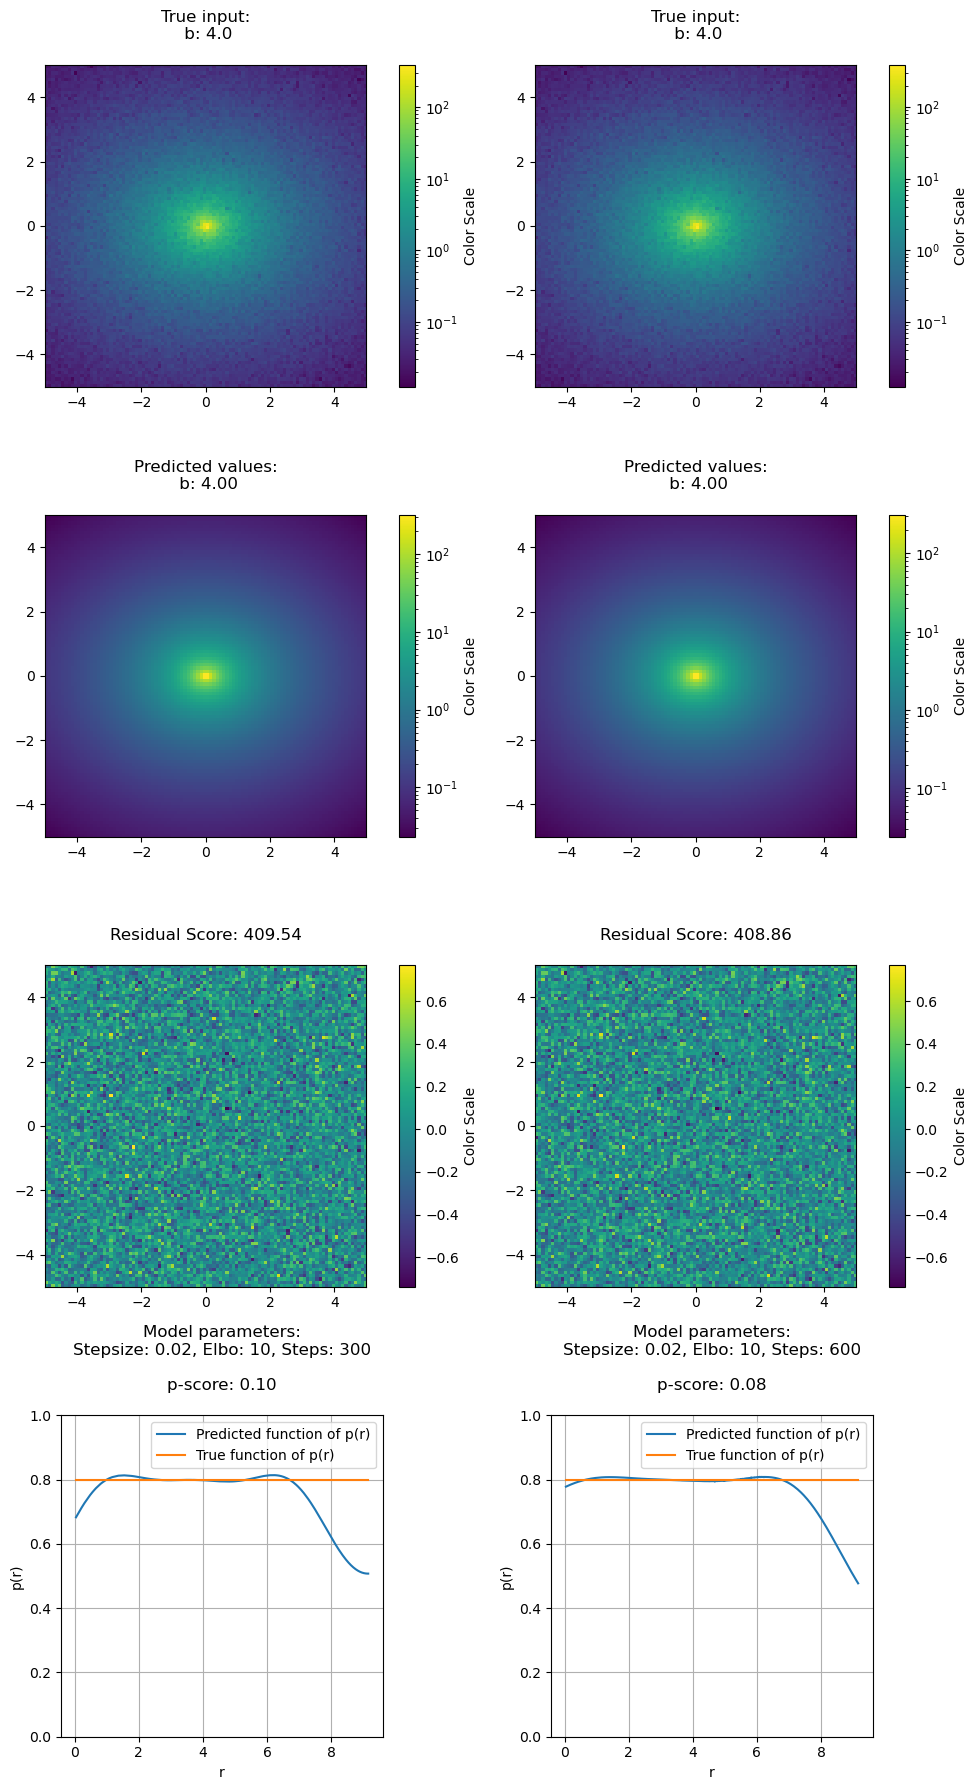

In [18]:
def model(rho_x, rho_y, rho_z, r, sigma_obs=None):
    #eps = 1e-12

    r_gp = jnp.linspace(jnp.min(r)-0.05,jnp.max(r)+0.5,1000)

    p0 = numpyro.sample('p0', dist.Uniform(0.001,1.)) # i.e. = p(0)
    p5 = numpyro.sample('p5', dist.Uniform(0.001,1.)) # i.e. = p(5)
    
    def linear_mean_function(r):
        return p0 + ((p5-p0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_p = numpyro.sample("sigma_p", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_p = numpyro.sample("length_scale_p", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_p = sigma_p**2 * kernels.ExpSquared(length_scale_p)
    gp_p = GaussianProcess(kernel_p, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    p_not_transformed = numpyro.sample("p_not_transformed", gp_p.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    p= numpyro.deterministic("p", jnp.clip(p_not_transformed+linear_mean_function(r_gp), min = 1e-10, max = 1.))
    interpolator = RegularGridInterpolator((r_gp,), p, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    p_final = interpolator(r)

    # Constant parameters
    q = 0.6
    e = 0.0
    rho0 = 1.0
    s = 1.0
    a = 2.0
    b = numpyro.deterministic("b",numpyro.sample('b_sample', dist.Uniform(1.0,5.0)))
    i = 0.0
    phi = 0.0
    theta = 0.0


    # Compute the density
    density = utils.rho(rho_x, rho_y, rho_z, e, e, 0., 0., 0., p_final, 0., 0., 0., q, rho0, s, a, b, i, phi, theta)

    sb = numpyro.deterministic("sb", jnp.sum(density, axis = 2))

    # Observation model
    numpyro.sample("sigma_obs", dist.TruncatedNormal(sb, 0.2 * sb,low = 1e-10), obs=sigma_obs)

model_name = "p(r)_b"

fig, axes = plt.subplots(4,2, figsize=(10,18))
for w in range(len(adam_params)):
    for j in range(len(elbo_params)):
        for k in range(len(steps_param)):
            for i in range(len(input_data)):
                print(adam_params[w],elbo_params[j],steps_param[k])
                results, guide = runsvi(adam_params[w],elbo_params[j],input_data[i],steps_param[k],rho_x,rho_y,rho_z,r)

                b_pred = results.params['b_sample_auto_loc']
                key = jax.random.PRNGKey(42)

                predictive = Predictive(guide, params=results.params, num_samples=1000)
                posterior_samples = predictive(key,rho_x,rho_y,rho_z,r)

                predictive = Predictive(model, posterior_samples, params=results.params, num_samples=1000)
                posterior_predictive_samples = predictive(key,rho_x,rho_y,rho_z,r)


                p_mean = posterior_predictive_samples['p'].mean(axis=0)
                p_std = posterior_predictive_samples['p'].std(axis=0)

                sb_mean = posterior_predictive_samples['sb'].mean(axis=0)
                sb_std = posterior_predictive_samples['sb'].std(axis=0)


                p1,p2,p3,p4 = p_input_params[input_index][0],p_input_params[input_index][1],p_input_params[input_index][2],p_input_params[input_index][3]
                
                b_score = float(score_const(b_def,b_pred))

                p_obs = p(r_gp,p1,p2,p3,p4)
            
                p_score = float(score_r(p_obs,p_mean))
                
                img_score = float(utils.ssd_score(input_data[i],sb_mean,sb_mean))
                total_score = img_score + p_score + b_score
                ph = None

                csv_entry = [model_name,input_p,ph,ph,adam_params[w],elbo_params[j],steps_param[k],ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,
                             ph,ph,ph,b_def,b_pred,b_score,ph,ph,ph,ph,ph,ph,ph,ph,ph,p_score,ph,ph,img_score,total_score]
                csv_results.append(csv_entry)

                
                ax1 = axes[0,k]
                ax2 = axes[1,k]
                ax3 = axes[2,k]
                ax4 = axes[3,k]

                img1 = ax1.imshow(input_data[i].T, norm=colors.LogNorm(vmin=input_data[i].min(), vmax=input_data[i].max()), origin='lower',extent = extents)
                fig.colorbar(img1, ax=ax1, label='Color Scale',fraction = 0.05)
                ax1.set_title("True input:\n b: {}\n".format(b_def))
                ax1.set_anchor((0.6, 0.5))

                img2 = ax2.imshow(sb_mean.T, norm=colors.LogNorm(vmin=sb_mean.min(), vmax=sb_mean.max()), origin='lower',extent = extents)
                fig.colorbar(img2, ax=ax2, label='Color Scale',fraction = 0.05)
                ax2.set_title("Predicted values:\n b: {:.2f}\n".format(b_pred))
                ax2.set_anchor((0.6, 0.5))

                residual = (input_data[i] - sb_mean)/sb_mean
                img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
                fig.colorbar(img3, ax=ax3, label='Color Scale',fraction = 0.05)
                ax3.set_title("Residual Score: {:.2f}\n".format(img_score))
                ax3.set_anchor((0.6, 0.5))
                
                ax4.plot(r_gp, p_mean, label="Predicted function of p(r)")
                ax4.plot(r_gp, p_obs, label="True function of p(r)")
                ax4.legend()
                ax4.set_xlabel('r')
                ax4.set_ylabel('p(r)')
                ax4.grid(True)
                ax4.set_ylim([0,1])
                ax4.set_title("Model parameters:\nStepsize: {}, Elbo: {}, Steps: {}\n\np-score: {:.2f}\n".format(adam_params[w],elbo_params[j],steps_param[k],p_score))
                asp = np.diff(ax4.get_xlim())[0] / np.diff(ax4.get_ylim())[0]
                ax4.set_aspect(asp)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("Z:\\Uni\Master_Astronomy\\GitHub\\JAX_deprojection\\SVI_notebooks\\p1\\plots\\"+input_p+"_"+model_name+".png")  
plt.show()

## p(r) + i

0.02 10 300


100%|██████████| 300/300 [02:34<00:00,  1.95it/s, init loss: 164812.6250, avg. loss [286-300]: -22880.3383]


0.02 10 600


100%|██████████| 600/600 [05:02<00:00,  1.98it/s, init loss: 164812.6250, avg. loss [571-600]: -22928.2032]


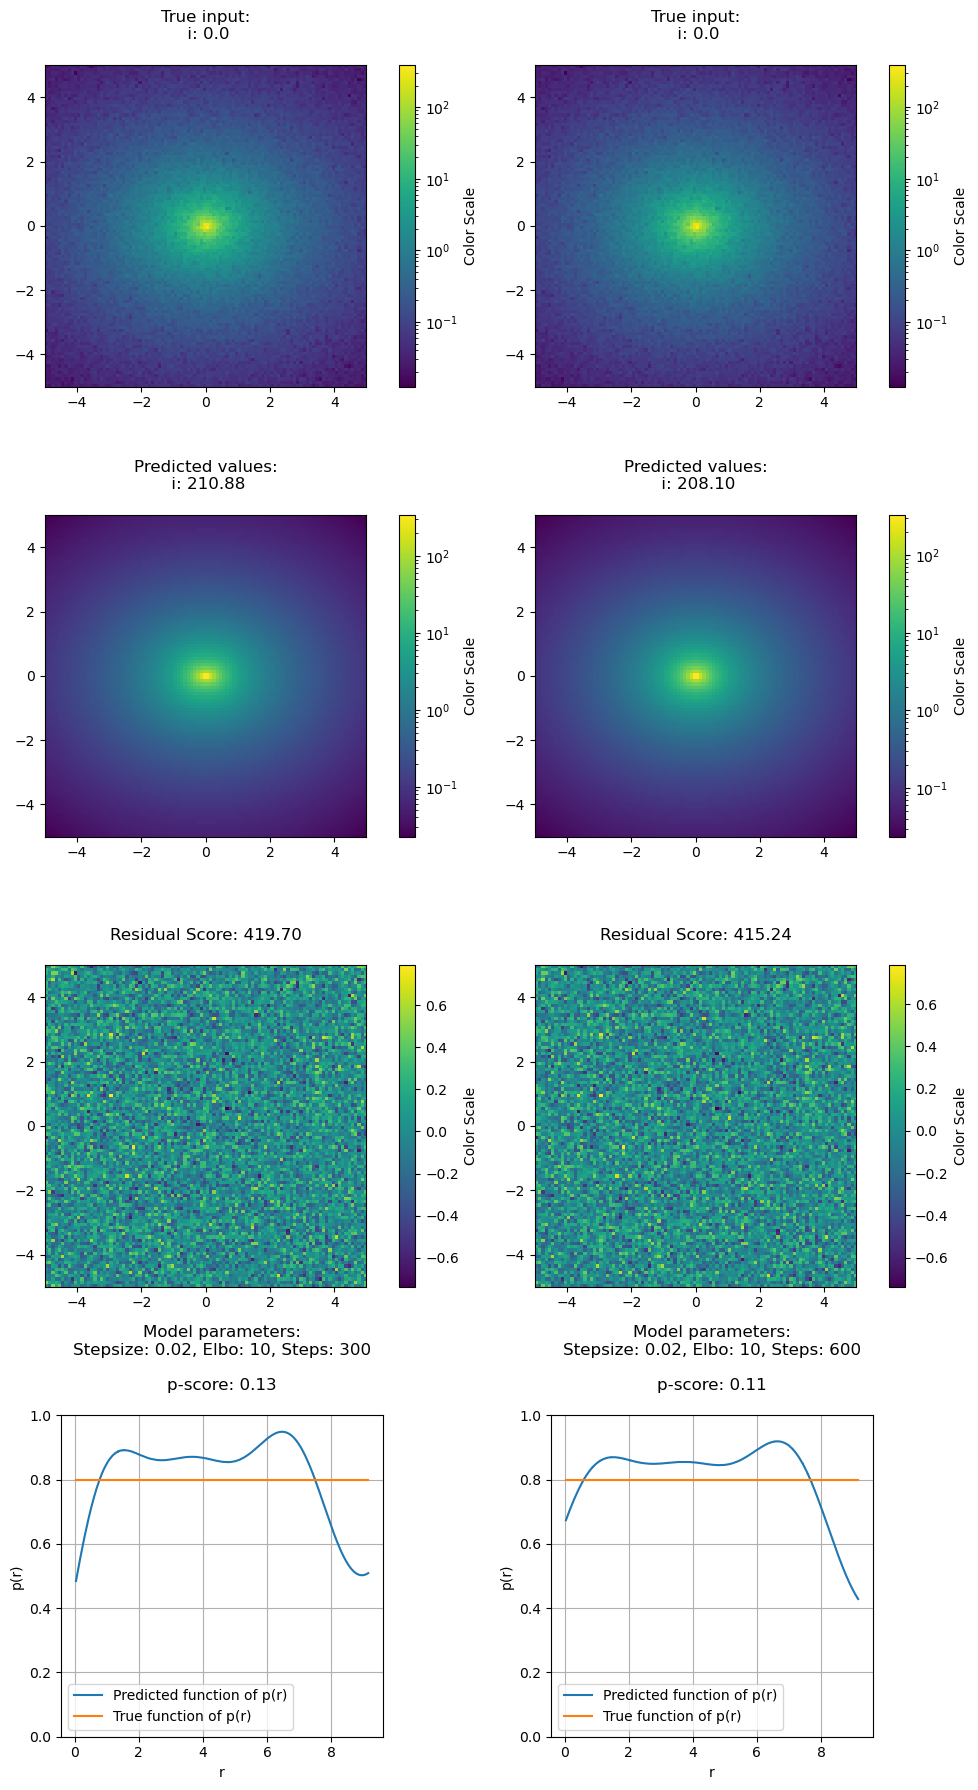

In [19]:
def model(rho_x, rho_y, rho_z, r, sigma_obs=None):
    #eps = 1e-12

    r_gp = jnp.linspace(jnp.min(r)-0.05,jnp.max(r)+0.5,1000)

    p0 = numpyro.sample('p0', dist.Uniform(0.001,1.)) # i.e. = p(0)
    p5 = numpyro.sample('p5', dist.Uniform(0.001,1.)) # i.e. = p(5)
    
    def linear_mean_function(r):
        return p0 + ((p5-p0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_p = numpyro.sample("sigma_p", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_p = numpyro.sample("length_scale_p", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_p = sigma_p**2 * kernels.ExpSquared(length_scale_p)
    gp_p = GaussianProcess(kernel_p, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    p_not_transformed = numpyro.sample("p_not_transformed", gp_p.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    p= numpyro.deterministic("p", jnp.clip(p_not_transformed+linear_mean_function(r_gp), min = 1e-10, max = 1.))
    interpolator = RegularGridInterpolator((r_gp,), p, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    p_final = interpolator(r)

    # Constant parameters
    q = 0.6
    e = 0.0
    rho0 = 1.0
    s = 1.0
    a = 2.0
    b = 4.0
    i = numpyro.deterministic("i",numpyro.sample('i_sample', dist.Uniform(0.,360.)))
    phi = 0.0
    theta = 0.0


    # Compute the density
    density = utils.rho(rho_x, rho_y, rho_z, e, e, 0., 0., 0., p_final, 0., 0., 0., q, rho0, s, a, b, i, phi, theta)

    sb = numpyro.deterministic("sb", jnp.sum(density, axis = 2))

    # Observation model
    numpyro.sample("sigma_obs", dist.TruncatedNormal(sb, 0.2 * sb,low = 1e-10), obs=sigma_obs)

model_name = "p(r)_i"

fig, axes = plt.subplots(4,2, figsize=(10,18))
for w in range(len(adam_params)):
    for j in range(len(elbo_params)):
        for k in range(len(steps_param)):
            for i in range(len(input_data)):
                print(adam_params[w],elbo_params[j],steps_param[k])
                results, guide = runsvi(adam_params[w],elbo_params[j],input_data[i],steps_param[k],rho_x,rho_y,rho_z,r)

                i_pred = results.params['i_sample_auto_loc']
                key = jax.random.PRNGKey(42)

                predictive = Predictive(guide, params=results.params, num_samples=1000)
                posterior_samples = predictive(key,rho_x,rho_y,rho_z,r)

                predictive = Predictive(model, posterior_samples, params=results.params, num_samples=1000)
                posterior_predictive_samples = predictive(key,rho_x,rho_y,rho_z,r)


                p_mean = posterior_predictive_samples['p'].mean(axis=0)
                p_std = posterior_predictive_samples['p'].std(axis=0)

                sb_mean = posterior_predictive_samples['sb'].mean(axis=0)
                sb_std = posterior_predictive_samples['sb'].std(axis=0)


                p1,p2,p3,p4 = p_input_params[input_index][0],p_input_params[input_index][1],p_input_params[input_index][2],p_input_params[input_index][3]
                
                i_score = float(score_const(i_def,i_pred))

                p_obs = p(r_gp,p1,p2,p3,p4)
            
                p_score = float(score_r(p_obs,p_mean))
                
                img_score = float(utils.ssd_score(input_data[i],sb_mean,sb_mean))
                total_score = img_score + p_score + i_score
                ph = None

                csv_entry = [model_name,input_p,ph,ph,adam_params[w],elbo_params[j],steps_param[k],ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,
                             ph,ph,ph,ph,ph,ph,i_def,i_pred,i_score,ph,ph,ph,ph,ph,ph,p_score,ph,ph,img_score,total_score]
                csv_results.append(csv_entry)

                
                ax1 = axes[0,k]
                ax2 = axes[1,k]
                ax3 = axes[2,k]
                ax4 = axes[3,k]

                img1 = ax1.imshow(input_data[i].T, norm=colors.LogNorm(vmin=input_data[i].min(), vmax=input_data[i].max()), origin='lower',extent = extents)
                fig.colorbar(img1, ax=ax1, label='Color Scale',fraction = 0.05)
                ax1.set_title("True input:\n i: {}\n".format(i_def))
                ax1.set_anchor((0.6, 0.5))

                img2 = ax2.imshow(sb_mean.T, norm=colors.LogNorm(vmin=sb_mean.min(), vmax=sb_mean.max()), origin='lower',extent = extents)
                fig.colorbar(img2, ax=ax2, label='Color Scale',fraction = 0.05)
                ax2.set_title("Predicted values:\n i: {:.2f}\n".format(i_pred))
                ax2.set_anchor((0.6, 0.5))

                residual = (input_data[i] - sb_mean)/sb_mean
                img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
                fig.colorbar(img3, ax=ax3, label='Color Scale',fraction = 0.05)
                ax3.set_title("Residual Score: {:.2f}\n".format(img_score))
                ax3.set_anchor((0.6, 0.5))
                
                ax4.plot(r_gp, p_mean, label="Predicted function of p(r)")
                ax4.plot(r_gp, p_obs, label="True function of p(r)")
                ax4.legend()
                ax4.set_xlabel('r')
                ax4.set_ylabel('p(r)')
                ax4.grid(True)
                ax4.set_ylim([0,1])
                ax4.set_title("Model parameters:\nStepsize: {}, Elbo: {}, Steps: {}\n\np-score: {:.2f}\n".format(adam_params[w],elbo_params[j],steps_param[k],p_score))
                asp = np.diff(ax4.get_xlim())[0] / np.diff(ax4.get_ylim())[0]
                ax4.set_aspect(asp)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("Z:\\Uni\Master_Astronomy\\GitHub\\JAX_deprojection\\SVI_notebooks\\p1\\plots\\"+input_p+"_"+model_name+".png")  
plt.show()

## p(r) + phi

0.02 10 300


100%|██████████| 300/300 [02:28<00:00,  2.02it/s, init loss: 306042.9062, avg. loss [286-300]: -22939.9647]


0.02 10 600


100%|██████████| 600/600 [04:57<00:00,  2.02it/s, init loss: 306042.9062, avg. loss [571-600]: -22958.6702]


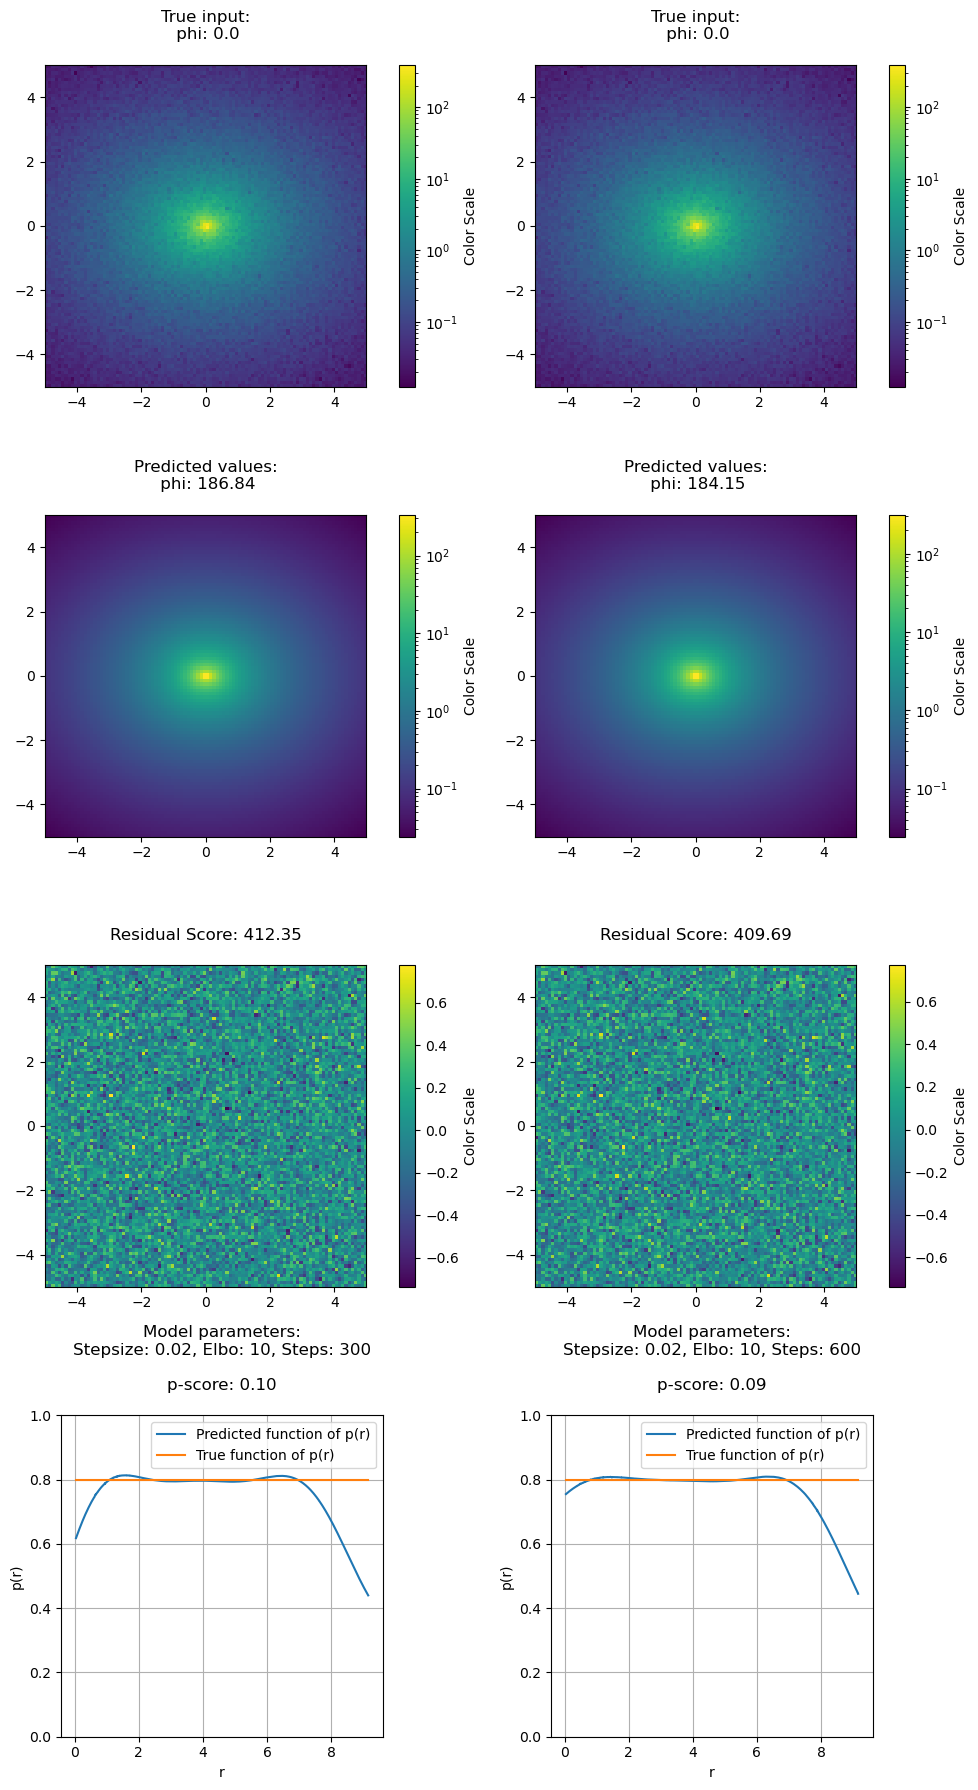

In [20]:
def model(rho_x, rho_y, rho_z, r, sigma_obs=None):
    #eps = 1e-12

    r_gp = jnp.linspace(jnp.min(r)-0.05,jnp.max(r)+0.5,1000)

    p0 = numpyro.sample('p0', dist.Uniform(0.001,1.)) # i.e. = p(0)
    p5 = numpyro.sample('p5', dist.Uniform(0.001,1.)) # i.e. = p(5)
    
    def linear_mean_function(r):
        return p0 + ((p5-p0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_p = numpyro.sample("sigma_p", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_p = numpyro.sample("length_scale_p", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_p = sigma_p**2 * kernels.ExpSquared(length_scale_p)
    gp_p = GaussianProcess(kernel_p, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    p_not_transformed = numpyro.sample("p_not_transformed", gp_p.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    p= numpyro.deterministic("p", jnp.clip(p_not_transformed+linear_mean_function(r_gp), min = 1e-10, max = 1.))
    interpolator = RegularGridInterpolator((r_gp,), p, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    p_final = interpolator(r)

    # Constant parameters
    q = 0.6
    e = 0.0
    rho0 = 1.0
    s = 1.0
    a = 2.0
    b = 4.0
    i = 0.0
    phi = numpyro.deterministic("phi",numpyro.sample('phi_sample', dist.Uniform(0.,360.)))
    theta = 0.0


    # Compute the density
    density = utils.rho(rho_x, rho_y, rho_z, e, e, 0., 0., 0., p_final, 0., 0., 0., q, rho0, s, a, b, i, phi, theta)

    sb = numpyro.deterministic("sb", jnp.sum(density, axis = 2))

    # Observation model
    numpyro.sample("sigma_obs", dist.TruncatedNormal(sb, 0.2 * sb,low = 1e-10), obs=sigma_obs)

model_name = "p(r)_phi"

fig, axes = plt.subplots(4,2, figsize=(10,18))
for w in range(len(adam_params)):
    for j in range(len(elbo_params)):
        for k in range(len(steps_param)):
            for i in range(len(input_data)):
                print(adam_params[w],elbo_params[j],steps_param[k])
                results, guide = runsvi(adam_params[w],elbo_params[j],input_data[i],steps_param[k],rho_x,rho_y,rho_z,r)

                phi_pred = results.params['phi_sample_auto_loc']
                key = jax.random.PRNGKey(42)

                predictive = Predictive(guide, params=results.params, num_samples=1000)
                posterior_samples = predictive(key,rho_x,rho_y,rho_z,r)

                predictive = Predictive(model, posterior_samples, params=results.params, num_samples=1000)
                posterior_predictive_samples = predictive(key,rho_x,rho_y,rho_z,r)


                p_mean = posterior_predictive_samples['p'].mean(axis=0)
                p_std = posterior_predictive_samples['p'].std(axis=0)

                sb_mean = posterior_predictive_samples['sb'].mean(axis=0)
                sb_std = posterior_predictive_samples['sb'].std(axis=0)


                p1,p2,p3,p4 = p_input_params[input_index][0],p_input_params[input_index][1],p_input_params[input_index][2],p_input_params[input_index][3]
                
                phi_score = float(score_const(phi_def,phi_pred))

                p_obs = p(r_gp,p1,p2,p3,p4)
            
                p_score = float(score_r(p_obs,p_mean))
                
                img_score = float(utils.ssd_score(input_data[i],sb_mean,sb_mean))
                total_score = img_score + p_score + phi_score
                ph = None

                csv_entry = [model_name,input_p,ph,ph,adam_params[w],elbo_params[j],steps_param[k],ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,
                             ph,ph,ph,ph,ph,ph,ph,ph,ph,phi_def,phi_pred,phi_score,ph,ph,ph,p_score,ph,ph,img_score,total_score]
                csv_results.append(csv_entry)

                
                ax1 = axes[0,k]
                ax2 = axes[1,k]
                ax3 = axes[2,k]
                ax4 = axes[3,k]

                img1 = ax1.imshow(input_data[i].T, norm=colors.LogNorm(vmin=input_data[i].min(), vmax=input_data[i].max()), origin='lower',extent = extents)
                fig.colorbar(img1, ax=ax1, label='Color Scale',fraction = 0.05)
                ax1.set_title("True input:\n phi: {}\n".format(phi_def))
                ax1.set_anchor((0.6, 0.5))

                img2 = ax2.imshow(sb_mean.T, norm=colors.LogNorm(vmin=sb_mean.min(), vmax=sb_mean.max()), origin='lower',extent = extents)
                fig.colorbar(img2, ax=ax2, label='Color Scale',fraction = 0.05)
                ax2.set_title("Predicted values:\n phi: {:.2f}\n".format(phi_pred))
                ax2.set_anchor((0.6, 0.5))

                residual = (input_data[i] - sb_mean)/sb_mean
                img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
                fig.colorbar(img3, ax=ax3, label='Color Scale',fraction = 0.05)
                ax3.set_title("Residual Score: {:.2f}\n".format(img_score))
                ax3.set_anchor((0.6, 0.5))
                
                ax4.plot(r_gp, p_mean, label="Predicted function of p(r)")
                ax4.plot(r_gp, p_obs, label="True function of p(r)")
                ax4.legend()
                ax4.set_xlabel('r')
                ax4.set_ylabel('p(r)')
                ax4.grid(True)
                ax4.set_ylim([0,1])
                ax4.set_title("Model parameters:\nStepsize: {}, Elbo: {}, Steps: {}\n\np-score: {:.2f}\n".format(adam_params[w],elbo_params[j],steps_param[k],p_score))
                asp = np.diff(ax4.get_xlim())[0] / np.diff(ax4.get_ylim())[0]
                ax4.set_aspect(asp)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("Z:\\Uni\Master_Astronomy\\GitHub\\JAX_deprojection\\SVI_notebooks\\p1\\plots\\"+input_p+"_"+model_name+".png")  
plt.show()

## p(r) + theta

0.02 10 300


100%|██████████| 300/300 [02:29<00:00,  2.01it/s, init loss: 560838.5000, avg. loss [286-300]: -22941.5061]


0.02 10 600


100%|██████████| 600/600 [04:40<00:00,  2.14it/s, init loss: 560838.5000, avg. loss [571-600]: -22961.2195]


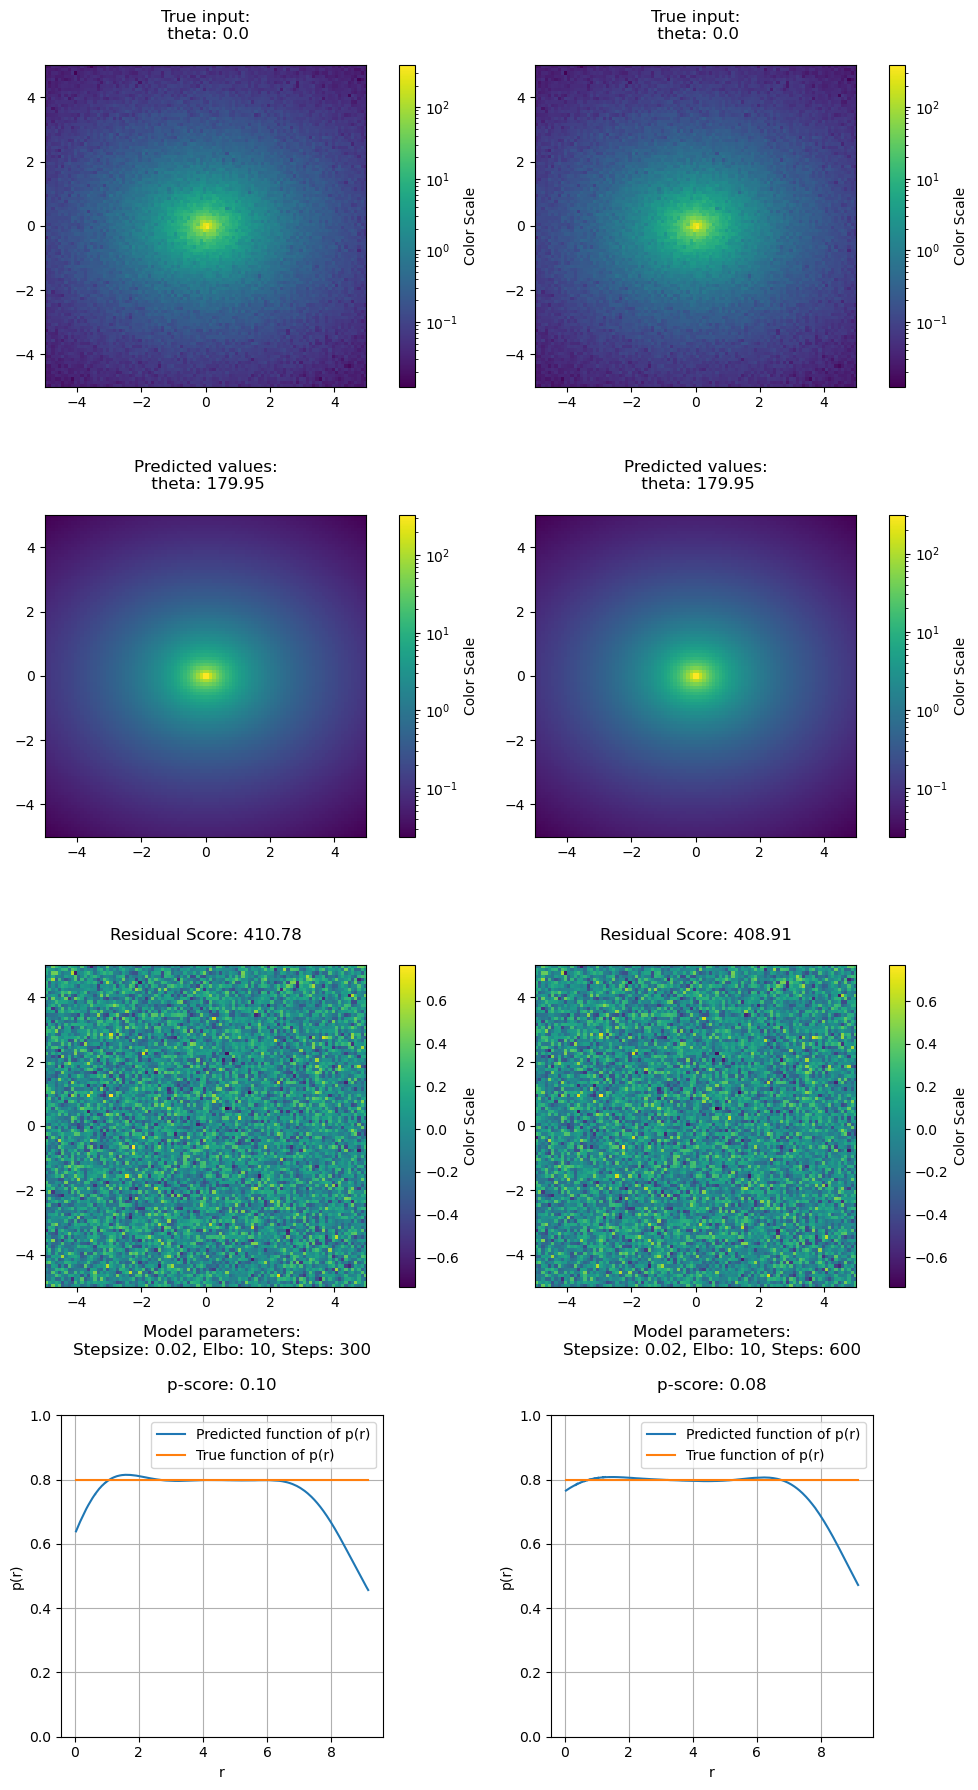

In [21]:
def model(rho_x, rho_y, rho_z, r, sigma_obs=None):
    #eps = 1e-12

    r_gp = jnp.linspace(jnp.min(r)-0.05,jnp.max(r)+0.5,1000)

    p0 = numpyro.sample('p0', dist.Uniform(0.001,1.)) # i.e. = p(0)
    p5 = numpyro.sample('p5', dist.Uniform(0.001,1.)) # i.e. = p(5)
    
    def linear_mean_function(r):
        return p0 + ((p5-p0)/5) * r
    
    
    # GP parameters for p(r)
    sigma_p = numpyro.sample("sigma_p", dist.TruncatedNormal(0.,0.1 ,low = 1e-10,high=3.))
    length_scale_p = numpyro.sample("length_scale_p", dist.Uniform(1.,5.)) 
    #sigma_p = 1.0
    #length_scale_p = 0.5 
    kernel_p = sigma_p**2 * kernels.ExpSquared(length_scale_p)
    gp_p = GaussianProcess(kernel_p, r_gp, diag=1e-5, mean=0.0)  #linear_mean_function
    p_not_transformed = numpyro.sample("p_not_transformed", gp_p.numpyro_dist())
    #p = numpyro.deterministic("p",jax.nn.sigmoid(p_not_transformed))
    p= numpyro.deterministic("p", jnp.clip(p_not_transformed+linear_mean_function(r_gp), min = 1e-10, max = 1.))
    interpolator = RegularGridInterpolator((r_gp,), p, method="linear", bounds_error=False, fill_value=None)

    # Interpolate the values
    p_final = interpolator(r)
 
    # Constant parameters
    q = 0.6
    e = 0.0
    rho0 = 1.0
    s = 1.0
    a = 2.0
    b = 4.0
    i = 0.0
    phi = 0.0
    theta = numpyro.deterministic("theta",numpyro.sample('theta_sample', dist.Uniform(0.,360.)))


    # Compute the density
    density = utils.rho(rho_x, rho_y, rho_z, e, e, 0., 0., 0., p_final, 0., 0., 0., q, rho0, s, a, b, i, phi, theta)

    sb = numpyro.deterministic("sb", jnp.sum(density, axis = 2))

    # Observation model
    numpyro.sample("sigma_obs", dist.TruncatedNormal(sb, 0.2 * sb,low = 1e-10), obs=sigma_obs)

model_name = "p(r)_theta"

fig, axes = plt.subplots(4,2, figsize=(10,18))
for w in range(len(adam_params)):
    for j in range(len(elbo_params)):
        for k in range(len(steps_param)):
            for i in range(len(input_data)):
                print(adam_params[w],elbo_params[j],steps_param[k])
                results, guide = runsvi(adam_params[w],elbo_params[j],input_data[i],steps_param[k],rho_x,rho_y,rho_z,r)

                theta_pred = results.params['theta_sample_auto_loc']
                key = jax.random.PRNGKey(42)

                predictive = Predictive(guide, params=results.params, num_samples=1000)
                posterior_samples = predictive(key,rho_x,rho_y,rho_z,r)

                predictive = Predictive(model, posterior_samples, params=results.params, num_samples=1000)
                posterior_predictive_samples = predictive(key,rho_x,rho_y,rho_z,r)


                p_mean = posterior_predictive_samples['p'].mean(axis=0)
                p_std = posterior_predictive_samples['p'].std(axis=0)

                sb_mean = posterior_predictive_samples['sb'].mean(axis=0)
                sb_std = posterior_predictive_samples['sb'].std(axis=0)


                p1,p2,p3,p4 = p_input_params[input_index][0],p_input_params[input_index][1],p_input_params[input_index][2],p_input_params[input_index][3]
                
                theta_score = float(score_const(theta_def,theta_pred))

                p_obs = p(r_gp,p1,p2,p3,p4)
            
                p_score = float(score_r(p_obs,p_mean))
                
                img_score = float(utils.ssd_score(input_data[i],sb_mean,sb_mean))
                total_score = img_score + p_score + theta_score
                ph = None

                csv_entry = [model_name,input_p,ph,ph,adam_params[w],elbo_params[j],steps_param[k],ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,
                             ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,ph,theta_def,theta_pred,theta_score,p_score,ph,ph,img_score,total_score]
                csv_results.append(csv_entry)

                
                ax1 = axes[0,k]
                ax2 = axes[1,k]
                ax3 = axes[2,k]
                ax4 = axes[3,k]

                img1 = ax1.imshow(input_data[i].T, norm=colors.LogNorm(vmin=input_data[i].min(), vmax=input_data[i].max()), origin='lower',extent = extents)
                fig.colorbar(img1, ax=ax1, label='Color Scale',fraction = 0.05)
                ax1.set_title("True input:\n theta: {}\n".format(theta_def))
                ax1.set_anchor((0.6, 0.5))

                img2 = ax2.imshow(sb_mean.T, norm=colors.LogNorm(vmin=sb_mean.min(), vmax=sb_mean.max()), origin='lower',extent = extents)
                fig.colorbar(img2, ax=ax2, label='Color Scale',fraction = 0.05)
                ax2.set_title("Predicted values:\n theta: {:.2f}\n".format(theta_pred))
                ax2.set_anchor((0.6, 0.5))

                residual = (input_data[i] - sb_mean)/sb_mean
                img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
                fig.colorbar(img3, ax=ax3, label='Color Scale',fraction = 0.05)
                ax3.set_title("Residual Score: {:.2f}\n".format(img_score))
                ax3.set_anchor((0.6, 0.5))
                
                ax4.plot(r_gp, p_mean, label="Predicted function of p(r)")
                ax4.plot(r_gp, p_obs, label="True function of p(r)")
                ax4.legend()
                ax4.set_xlabel('r')
                ax4.set_ylabel('p(r)')
                ax4.grid(True)
                ax4.set_ylim([0,1])
                ax4.set_title("Model parameters:\nStepsize: {}, Elbo: {}, Steps: {}\n\np-score: {:.2f}\n".format(adam_params[w],elbo_params[j],steps_param[k],p_score))
                asp = np.diff(ax4.get_xlim())[0] / np.diff(ax4.get_ylim())[0]
                ax4.set_aspect(asp)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig("Z:\\Uni\Master_Astronomy\\GitHub\\JAX_deprojection\\SVI_notebooks\\p1\\plots\\"+input_p+"_"+model_name+".png")  
plt.show()

In [22]:
import pandas as pd
df = pd.DataFrame(csv_results, columns=["Model Name","Input p","Input q","Input e","Adam Stepsize","Elbo Stepsize","Steps", "q_def","q_pred","e_def","e_pred","rho0_def","rho0_pred","rho0_score","s_def","s_pred","s_score",
                             "a_def","a_pred","a_score","b_def","b_pred","b_score","i_def","i_pred","i_score","phi_def","phi_pred","phi_score","theta_def","theta_pred","theta_score","p_score","q_score","e_score","img_score","total_score"])

In [23]:
df

,Model Name,Input p,Input q,Input e,Adam Stepsize,Elbo Stepsize,Steps,q_def,q_pred,e_def,...,phi_pred,phi_score,theta_def,theta_pred,theta_score,p_score,q_score,e_score,img_score,total_score
0,p(r)_q,const_high,None,None,0.02,10,300,0.6,0.51071763,NaN,...,None,NaN,NaN,None,NaN,0.107714,0.089282,NaN,403.432404,403.629400
1,p(r)_q,const_high,None,None,0.02,10,600,0.6,0.53369814,NaN,...,None,NaN,NaN,None,NaN,0.096157,0.066302,NaN,403.623535,403.785994
2,p(r)_e,const_high,None,None,0.02,10,300,NaN,None,0.0,...,None,NaN,NaN,None,NaN,0.058757,NaN,0.019328,550.203979,550.282064
3,p(r)_e,const_high,None,None,0.02,10,600,NaN,None,0.0,...,None,NaN,NaN,None,NaN,0.038171,NaN,0.008633,439.431274,439.478078
4,p(r)_rho0,const_high,None,None,0.02,10,300,NaN,None,NaN,...,None,NaN,NaN,None,NaN,0.098550,NaN,NaN,1054.943604,1055.241562
5,p(r)_rho0,const_high,None,None,0.02,10,600,NaN,None,NaN,...,None,NaN,NaN,None,NaN,0.089274,NaN,NaN,707.132751,707.361244
6,p(r)_s,const_high,None,None,0.02,10,300,NaN,None,NaN,...,None,NaN,NaN,None,NaN,0.121911,NaN,NaN,412.783386,412.905971
7,p(r)_s,const_high,None,None,0.02,10,600,NaN,None,NaN,...,None,NaN,NaN,None,NaN,0.098200,NaN,NaN,409.193451,409.291671
8,p(r)_a,const_high,None,None,0.02,10,300,NaN,None,NaN,...,None,NaN,NaN,None,NaN,0.122513,NaN,NaN,410.208923,410.362057
9,p(r)_a,const_high,None,None,0.02,10,600,NaN,None,NaN,...,None,NaN,NaN,None,NaN,0.103392,NaN,NaN,409.329346,409.434708


In [24]:
df.to_pickle("Z:\\Uni\\Master_Astronomy\\GitHub\\JAX_deprojection\\SVI_notebooks\\p1\\table\\"+input_p+"_"+model_name+".pkl")